## ❓ Pertanyaan 1:
> **Tolong turunkan matrix covariance untuk Squared Exponential dan dijabarkan penulisan matematika menggunakan symbol dan notasi. Untuk penjelasan menggunakan kalimat, gunakan sedikit saja. Saya hanya tertarik dengan persamaan matematikanya. Tulis persamaan matematikanya yang lengkap dan runut.**

---

## 💡 Jawaban 1

### 1. Definisi Notasi & Simbol

* Matriks Data Input:
  $$X = \begin{bmatrix} \mathbf{x}_1^T \\ \mathbf{x}_2^T \\ \vdots \\ \mathbf{x}_N^T \end{bmatrix} \in \mathbb{R}^{N \times D}, \quad \mathbf{x}_p = \begin{bmatrix} x_{p,1} \\ x_{p,2} \\ \vdots \\ x_{p,D} \end{bmatrix} \in \mathbb{R}^D$$

* Jarak Kuadrat Euclidean antara $\mathbf{x}_p$ dan $\mathbf{x}_q$:
  $$r_{pq}^2 = \|\mathbf{x}_p - \mathbf{x}_q\|^2 = \sum_{d=1}^D (x_{p,d} - x_{q,d})^2 = (\mathbf{x}_p - \mathbf{x}_q)^T (\mathbf{x}_p - \mathbf{x}_q)$$

* Matriks Jarak Kuadrat $D^2 \in \mathbb{R}^{N \times N}$:
  $$[D^2]_{pq} = r_{pq}^2 = \|\mathbf{x}_p - \mathbf{x}_q\|^2$$

* Fungsi Kernel *Squared Exponential* (SE / Isotropik):
  $$k(\mathbf{x}_p, \mathbf{x}_q) = \sigma_f^2 \exp\left( -\frac{\|\mathbf{x}_p - \mathbf{x}_q\|^2}{2l^2} \right) = \sigma_f^2 \exp\left( -\frac{r_{pq}^2}{2l^2} \right)$$

* Vektor Hyperparameter:
  $$\boldsymbol{\theta} = \begin{bmatrix} \sigma_f^2 \\ l \\ \sigma_n^2 \end{bmatrix} \quad \text{atau} \quad \boldsymbol{\theta} = \begin{bmatrix} \sigma_f \\ l \\ \sigma_n \end{bmatrix}$$

---

### 2. Formulasi Matriks Kovarians $K$ dan $K_y$

* Matriks Kovarians Fungsi Laten $K \in \mathbb{R}^{N \times N}$:
  $$K = \begin{bmatrix}
  k(\mathbf{x}_1, \mathbf{x}_1) & k(\mathbf{x}_1, \mathbf{x}_2) & \cdots & k(\mathbf{x}_1, \mathbf{x}_N) \\
  k(\mathbf{x}_2, \mathbf{x}_1) & k(\mathbf{x}_2, \mathbf{x}_2) & \cdots & k(\mathbf{x}_2, \mathbf{x}_N) \\
  \vdots & \vdots & \ddots & \vdots \\
  k(\mathbf{x}_N, \mathbf{x}_1) & k(\mathbf{x}_N, \mathbf{x}_2) & \cdots & k(\mathbf{x}_N, \mathbf{x}_N)
  \end{bmatrix}, \quad [K]_{pq} = k(\mathbf{x}_p, \mathbf{x}_q)$$

* Matriks Kovarians Data Observasi Ber-noise $K_y \in \mathbb{R}^{N \times N}$:
  $$K_y = K + \sigma_n^2 I_N$$

* Elemen Skalar $[K_y]_{pq}$:
  $$[K_y]_{pq} = \sigma_f^2 \exp\left( -\frac{\|\mathbf{x}_p - \mathbf{x}_q\|^2}{2l^2} \right) + \sigma_n^2 \delta_{pq}$$
  dengan Kronecker delta:
  $$\delta_{pq} = \begin{cases} 1, & p = q \\ 0, & p \neq q \end{cases}$$

---

### 3. Penurunan Parsial Skalar (Elemen $[K]_{pq}$ dan $[K_y]_{pq}$)

#### a. Turunan terhadap Signal Variance ($\sigma_f^2$) dan Signal Amplitude ($\sigma_f$)
* **Terhadap $\sigma_f^2$**:
  $$\begin{aligned}
  \frac{\partial [K]_{pq}}{\partial \sigma_f^2} &= \frac{\partial}{\partial \sigma_f^2} \left[ \sigma_f^2 \exp\left( -\frac{r_{pq}^2}{2l^2} \right) \right] \\
  &= \exp\left( -\frac{r_{pq}^2}{2l^2} \right) \\
  &= \frac{1}{\sigma_f^2} [K]_{pq}
  \end{aligned}$$

* **Terhadap $\sigma_f$** (via Chain Rule $\frac{\partial}{\partial \sigma_f} = \frac{\partial \sigma_f^2}{\partial \sigma_f} \frac{\partial}{\partial \sigma_f^2} = 2\sigma_f \frac{\partial}{\partial \sigma_f^2}$):
  $$\begin{aligned}
  \frac{\partial [K]_{pq}}{\partial \sigma_f} &= \frac{\partial}{\partial \sigma_f} \left[ \sigma_f^2 \exp\left( -\frac{r_{pq}^2}{2l^2} \right) \right] \\
  &= 2\sigma_f \exp\left( -\frac{r_{pq}^2}{2l^2} \right) \\
  &= \frac{2}{\sigma_f} [K]_{pq}
  \end{aligned}$$

* **Terhadap Parameter Log-Space $\tilde{\theta}_f = \log \sigma_f$** ($\sigma_f = e^{\tilde{\theta}_f}$):
  $$\frac{\partial [K]_{pq}}{\partial \log \sigma_f} = \sigma_f \frac{\partial [K]_{pq}}{\partial \sigma_f} = \sigma_f \left( \frac{2}{\sigma_f} [K]_{pq} \right) = 2 [K]_{pq}$$

---

#### b. Turunan terhadap Lengthscale ($l$)
* Definisikan fungsi eksponen $u(l)$:
  $$u(l) = -\frac{r_{pq}^2}{2l^2} = -\frac{1}{2} r_{pq}^2 l^{-2}$$

* Turunan parsial $u(l)$ terhadap $l$:
  $$\frac{\partial u}{\partial l} = -\frac{1}{2} r_{pq}^2 (-2 l^{-3}) = \frac{r_{pq}^2}{l^3}$$

* Turunan parsial $[K]_{pq}$ terhadap $l$ via Chain Rule:
  $$\begin{aligned}
  \frac{\partial [K]_{pq}}{\partial l} &= \frac{\partial}{\partial l} \left[ \sigma_f^2 \exp(u(l)) \right] \\
  &= \sigma_f^2 \exp(u(l)) \cdot \frac{\partial u}{\partial l} \\
  &= \sigma_f^2 \exp\left( -\frac{r_{pq}^2}{2l^2} \right) \cdot \left( \frac{r_{pq}^2}{l^3} \right) \\
  &= [K]_{pq} \left( \frac{r_{pq}^2}{l^3} \right) = [K]_{pq} \left( \frac{\|\mathbf{x}_p - \mathbf{x}_q\|^2}{l^3} \right)
  \end{aligned}$$

* **Terhadap Parameter Log-Space $\tilde{\theta}_l = \log l$** ($l = e^{\tilde{\theta}_l}$):
  $$\begin{aligned}
  \frac{\partial [K]_{pq}}{\partial \log l} &= l \frac{\partial [K]_{pq}}{\partial l} \\
  &= l \cdot \left[ [K]_{pq} \left( \frac{r_{pq}^2}{l^3} \right) \right] \\
  &= [K]_{pq} \left( \frac{r_{pq}^2}{l^2} \right) = [K]_{pq} \left( \frac{\|\mathbf{x}_p - \mathbf{x}_q\|^2}{l^2} \right)
  \end{aligned}$$

---

#### c. Kasus Khusus: Automatic Relevance Determination (ARD)
* Kernel ARD dengan $l_d$ terpisah untuk setiap dimensi $d \in \{1, \dots, D\}$:
  $$k(\mathbf{x}_p, \mathbf{x}_q) = \sigma_f^2 \exp\left( -\frac{1}{2} \sum_{d=1}^D \frac{(x_{p,d} - x_{q,d})^2}{l_d^2} \right)$$

* Turunan terhadap $l_m$ (dimensi ke-$m$):
  $$\begin{aligned}
  \frac{\partial [K]_{pq}}{\partial l_m} &= [K]_{pq} \cdot \frac{\partial}{\partial l_m} \left( -\frac{1}{2} \frac{(x_{p,m} - x_{q,m})^2}{l_m^2} \right) \\
  &= [K]_{pq} \left( \frac{(x_{p,m} - x_{q,m})^2}{l_m^3} \right)
  \end{aligned}$$

* **Terhadap $\log l_m$**:
  $$\frac{\partial [K]_{pq}}{\partial \log l_m} = l_m \frac{\partial [K]_{pq}}{\partial l_m} = [K]_{pq} \left( \frac{(x_{p,m} - x_{q,m})^2}{l_m^2} \right)$$

---

#### d. Turunan terhadap Noise Variance ($\sigma_n^2$) dan Noise Amplitude ($\sigma_n$)
Karena $[K_y]_{pq} = [K]_{pq} + \sigma_n^2 \delta_{pq}$ dan $[K]_{pq}$ independen terhadap $\sigma_n$:

* **Terhadap $\sigma_n^2$**:
  $$\frac{\partial [K_y]_{pq}}{\partial \sigma_n^2} = \frac{\partial}{\partial \sigma_n^2} \left[ [K]_{pq} + \sigma_n^2 \delta_{pq} \right] = \delta_{pq}$$

* **Terhadap $\sigma_n$**:
  $$\frac{\partial [K_y]_{pq}}{\partial \sigma_n} = \frac{\partial}{\partial \sigma_n} \left[ [K]_{pq} + \sigma_n^2 \delta_{pq} \right] = 2\sigma_n \delta_{pq}$$

* **Terhadap Parameter Log-Space $\tilde{\theta}_n = \log \sigma_n$**:
  $$\frac{\partial [K_y]_{pq}}{\partial \log \sigma_n} = \sigma_n \frac{\partial [K_y]_{pq}}{\partial \sigma_n} = \sigma_n (2\sigma_n \delta_{pq}) = 2\sigma_n^2 \delta_{pq}$$

---

### 4. Representasi Turunan Matriks Penuh (Matrix Form)

Notasi Hadamard Product (perkalian elemen-per-elemen $\odot$):

1. **Turunan Matriks Kovarians terhadap $\sigma_f^2$, $\sigma_f$, dan $\log \sigma_f$**:
   $$\frac{\partial K_y}{\partial \sigma_f^2} = \frac{1}{\sigma_f^2} K$$
   $$\frac{\partial K_y}{\partial \sigma_f} = \frac{2}{\sigma_f} K$$
   $$\frac{\partial K_y}{\partial \log \sigma_f} = 2 K$$

2. **Turunan Matriks Kovarians terhadap $l$ dan $\log l$**:
   $$\frac{\partial K_y}{\partial l} = \frac{1}{l^3} \left( D^2 \odot K \right)$$
   $$\frac{\partial K_y}{\partial \log l} = \frac{1}{l^2} \left( D^2 \odot K \right)$$
   dengan $[D^2]_{pq} = \|\mathbf{x}_p - \mathbf{x}_q\|^2$.

3. **Turunan Matriks Kovarians terhadap $\sigma_n^2$, $\sigma_n$, dan $\log \sigma_n$**:
   $$\frac{\partial K_y}{\partial \sigma_n^2} = I_N$$
   $$\frac{\partial K_y}{\partial \sigma_n} = 2\sigma_n I_N$$
   $$\frac{\partial K_y}{\partial \log \sigma_n} = 2\sigma_n^2 I_N$$

---

### 5. Bentuk Matriks Eksplisit $N \times N$

* **Matriks $\frac{\partial K_y}{\partial \sigma_f^2}$**:
  $$\frac{\partial K_y}{\partial \sigma_f^2} = \begin{bmatrix}
  1 & \exp\left(-\frac{r_{12}^2}{2l^2}\right) & \cdots & \exp\left(-\frac{r_{1N}^2}{2l^2}\right) \\
  \exp\left(-\frac{r_{21}^2}{2l^2}\right) & 1 & \cdots & \exp\left(-\frac{r_{2N}^2}{2l^2}\right) \\
  \vdots & \vdots & \ddots & \vdots \\
  \exp\left(-\frac{r_{N1}^2}{2l^2}\right) & \exp\left(-\frac{r_{N2}^2}{2l^2}\right) & \cdots & 1
  \end{bmatrix}$$

* **Matriks $\frac{\partial K_y}{\partial l}$**:
  $$\frac{\partial K_y}{\partial l} = \frac{\sigma_f^2}{l^3} \begin{bmatrix}
  0 & r_{12}^2 \exp\left(-\frac{r_{12}^2}{2l^2}\right) & \cdots & r_{1N}^2 \exp\left(-\frac{r_{1N}^2}{2l^2}\right) \\
  r_{21}^2 \exp\left(-\frac{r_{21}^2}{2l^2}\right) & 0 & \cdots & r_{2N}^2 \exp\left(-\frac{r_{2N}^2}{2l^2}\right) \\
  \vdots & \vdots & \ddots & \vdots \\
  r_{N1}^2 \exp\left(-\frac{r_{N1}^2}{2l^2}\right) & r_{N2}^2 \exp\left(-\frac{r_{N2}^2}{2l^2}\right) & \cdots & 0
  \end{bmatrix}$$
  *(Catatan: diagonal bernilai $0$ karena $r_{ii}^2 = \|\mathbf{x}_i - \mathbf{x}_i\|^2 = 0$)*

* **Matriks $\frac{\partial K_y}{\partial \sigma_n^2}$**:
  $$\frac{\partial K_y}{\partial \sigma_n^2} = \begin{bmatrix}
  1 & 0 & \cdots & 0 \\
  0 & 1 & \cdots & 0 \\
  \vdots & \vdots & \ddots & \vdots \\
  0 & 0 & \cdots & 1
  \end{bmatrix} = I_N$$


## ❓ Pertanyaan 2:
> **Tolong tuliskan turunan persamaan fungsi objektif marginal likelihood. dengan menjabarkan bentuk-bentuknya seperti matrixnya.**

---

## 💡 Jawaban 2

### 1. Formulasi Fungsi Objektif Log Marginal Likelihood & NLML

* **Log Marginal Likelihood (LML, $\mathcal{L}(\boldsymbol{\theta})$)**:
  $$\mathcal{L}(\boldsymbol{\theta}) = \log p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \underbrace{-\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}}_{T_1 \text{ (Data-fit)}} \underbrace{-\frac{1}{2} \log \det(K_y)}_{T_2 \text{ (Complexity Penalty)}} \underbrace{-\frac{N}{2} \log(2\pi)}_{T_3 \text{ (Normalization)}}$$

* **Negative Log Marginal Likelihood (NLML, $\operatorname{NLML}(\boldsymbol{\theta})$)**:
  $$\operatorname{NLML}(\boldsymbol{\theta}) = -\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} + \frac{1}{2} \log \det(K_y) + \frac{N}{2} \log(2\pi)$$

---

### 2. Teorema & Identitas Kalkulus Matriks

1. **Identitas Turunan Invers Matriks**:
   $$\frac{\partial K_y^{-1}}{\partial \theta_j} = -K_y^{-1} \frac{\partial K_y}{\partial \theta_j} K_y^{-1}$$
   *Pembuktian*:
   $$\begin{aligned}
   K_y K_y^{-1} &= I_N \\
   \frac{\partial (K_y K_y^{-1})}{\partial \theta_j} &= \mathbf{0} \\
   \frac{\partial K_y}{\partial \theta_j} K_y^{-1} + K_y \frac{\partial K_y^{-1}}{\partial \theta_j} &= \mathbf{0} \\
   K_y \frac{\partial K_y^{-1}}{\partial \theta_j} &= -\frac{\partial K_y}{\partial \theta_j} K_y^{-1} \\
   \frac{\partial K_y^{-1}}{\partial \theta_j} &= -K_y^{-1} \frac{\partial K_y}{\partial \theta_j} K_y^{-1}
   \end{aligned}$$

2. **Identitas Turunan Determinan Matriks (Jacobi's Formula)**:
   $$\frac{\partial \log \det(K_y)}{\partial \theta_j} = \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right)$$
   *Pembuktian*:
   $$\frac{\partial \log \det(K_y)}{\partial \theta_j} = \frac{1}{\det(K_y)} \frac{\partial \det(K_y)}{\partial \theta_j} = \frac{1}{\det(K_y)} \operatorname{tr}\left( \operatorname{adj}(K_y) \frac{\partial K_y}{\partial \theta_j} \right) = \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right)$$

3. **Sifat Siklik & Skalar dari Trace Matrix**:
   Untuk sebarang vektor $\mathbf{a} \in \mathbb{R}^N$ dan matriks $M \in \mathbb{R}^{N \times N}$:
   $$\mathbf{a}^T M \mathbf{a} = \operatorname{tr}(\mathbf{a}^T M \mathbf{a}) = \operatorname{tr}(\mathbf{a} \mathbf{a}^T M)$$

---

### 3. Penurunan Aljabar Parsial Suku per Suku

* **Suku Pertama ($T_1 = -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}$)**:
  $$\begin{aligned}
  \frac{\partial T_1}{\partial \theta_j} &= -\frac{1}{2} \mathbf{y}^T \left( \frac{\partial K_y^{-1}}{\partial \theta_j} \right) \mathbf{y} \\
  &= -\frac{1}{2} \mathbf{y}^T \left( -K_y^{-1} \frac{\partial K_y}{\partial \theta_j} K_y^{-1} \right) \mathbf{y} \\
  &= \frac{1}{2} \left( \mathbf{y}^T K_y^{-1} \right) \frac{\partial K_y}{\partial \theta_j} \left( K_y^{-1} \mathbf{y} \right)
  \end{aligned}$$
  Definisikan vektor prediktif $\boldsymbol{\alpha} \in \mathbb{R}^N$:
  $$\boldsymbol{\alpha} = K_y^{-1} \mathbf{y} \implies \boldsymbol{\alpha}^T = \mathbf{y}^T K_y^{-1} \quad (\text{karena } K_y = K_y^T)$$
  Maka:
  $$\frac{\partial T_1}{\partial \theta_j} = \frac{1}{2} \boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \boldsymbol{\alpha} = \frac{1}{2} \operatorname{tr}\left( \boldsymbol{\alpha} \boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \right)$$

* **Suku Kedua ($T_2 = -\frac{1}{2} \log \det(K_y)$)**:
  $$\frac{\partial T_2}{\partial \theta_j} = -\frac{1}{2} \frac{\partial \log \det(K_y)}{\partial \theta_j} = -\frac{1}{2} \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right)$$

* **Suku Ketiga ($T_3 = -\frac{N}{2} \log(2\pi)$)**:
  $$\frac{\partial T_3}{\partial \theta_j} = 0$$

---

### 4. Penggabungan Turunan Parsial Matriks (Persamaan 5.9 Rasmussen & Williams, 2006)

* **Gradien Log Marginal Likelihood ($\frac{\partial \mathcal{L}}{\partial \theta_j}$)**:
  $$\begin{aligned}
  \frac{\partial \mathcal{L}}{\partial \theta_j} &= \frac{\partial T_1}{\partial \theta_j} + \frac{\partial T_2}{\partial \theta_j} + \frac{\partial T_3}{\partial \theta_j} \\
  &= \frac{1}{2} \operatorname{tr}\left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \right) - \frac{1}{2} \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right) \\
  &= \frac{1}{2} \operatorname{tr}\left( \left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1} \right) \frac{\partial K_y}{\partial \theta_j} \right)
  \end{aligned}$$

* **Gradien Negative Log Marginal Likelihood ($\frac{\partial \operatorname{NLML}}{\partial \theta_j}$)**:
  $$\frac{\partial \operatorname{NLML}}{\partial \theta_j} = -\frac{\partial \mathcal{L}}{\partial \theta_j} = \frac{1}{2} \operatorname{tr}\left( \left( K_y^{-1} - \boldsymbol{\alpha}\boldsymbol{\alpha}^T \right) \frac{\partial K_y}{\partial \theta_j} \right)$$

* **Dalam Parameter Log-Space $\tilde{\theta}_j = \log \theta_j$** ($\theta_j = e^{\tilde{\theta}_j}$):
  $$\frac{\partial \mathcal{L}}{\partial \log \theta_j} = \theta_j \frac{\partial \mathcal{L}}{\partial \theta_j} = \frac{1}{2} \operatorname{tr}\left( \left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1} \right) \frac{\partial K_y}{\partial \log \theta_j} \right)$$

---

### 5. Penjabaran Eksplisit Bentuk Matriks Komponen $N \times N$

* **1. Vektor $\boldsymbol{\alpha} \in \mathbb{R}^{N \times 1}$**:
  $$\boldsymbol{\alpha} = K_y^{-1} \mathbf{y} = \begin{bmatrix} \alpha_1 \\ \alpha_2 \\ \vdots \\ \alpha_N \end{bmatrix}$$

* **2. Matriks Outer Product $\boldsymbol{\alpha}\boldsymbol{\alpha}^T \in \mathbb{R}^{N \times N}$ (Rank-1 Matrix)**:
  $$\boldsymbol{\alpha}\boldsymbol{\alpha}^T = \begin{bmatrix}
  \alpha_1^2 & \alpha_1 \alpha_2 & \cdots & \alpha_1 \alpha_N \\
  \alpha_2 \alpha_1 & \alpha_2^2 & \cdots & \alpha_2 \alpha_N \\
  \vdots & \vdots & \ddots & \vdots \\
  \alpha_N \alpha_1 & \alpha_N \alpha_2 & \cdots & \alpha_N^2
  \end{bmatrix}$$

* **3. Matriks Invers Kovarians $K_y^{-1} \in \mathbb{R}^{N \times N}$**:
  $$K_y^{-1} = \begin{bmatrix}
  [K_y^{-1}]_{11} & [K_y^{-1}]_{12} & \cdots & [K_y^{-1}]_{1N} \\
  [K_y^{-1}]_{21} & [K_y^{-1}]_{22} & \cdots & [K_y^{-1}]_{2N} \\
  \vdots & \vdots & \ddots & \vdots \\
  [K_y^{-1}]_{N1} & [K_y^{-1}]_{N2} & \cdots & [K_y^{-1}]_{NN}
  \end{bmatrix}$$

* **4. Matriks Bobot $W = (\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}) \in \mathbb{R}^{N \times N}$**:
  $$W = \begin{bmatrix}
  \alpha_1^2 - [K_y^{-1}]_{11} & \alpha_1 \alpha_2 - [K_y^{-1}]_{12} & \cdots & \alpha_1 \alpha_N - [K_y^{-1}]_{1N} \\
  \alpha_2 \alpha_1 - [K_y^{-1}]_{21} & \alpha_2^2 - [K_y^{-1}]_{22} & \cdots & \alpha_2 \alpha_N - [K_y^{-1}]_{2N} \\
  \vdots & \vdots & \ddots & \vdots \\
  \alpha_N \alpha_1 - [K_y^{-1}]_{N1} & \alpha_N \alpha_2 - [K_y^{-1}]_{N2} & \cdots & \alpha_N^2 - [K_y^{-1}]_{NN}
  \end{bmatrix}$$

* **5. Perhitungan Skalar Trace $\operatorname{tr}\left( W \frac{\partial K_y}{\partial \theta_j} \right)$ via Penjumlahan Elemen**:
  $$\begin{aligned}
  \frac{\partial \mathcal{L}}{\partial \theta_j} &= \frac{1}{2} \sum_{p=1}^N \sum_{q=1}^N W_{pq} \left[ \frac{\partial K_y}{\partial \theta_j} \right]_{qp} \\
  &= \frac{1}{2} \sum_{p=1}^N \sum_{q=1}^N \left( \alpha_p \alpha_q - [K_y^{-1}]_{pq} \right) \left[ \frac{\partial K_y}{\partial \theta_j} \right]_{pq}
  \end{aligned}$$
  *(karena $W$ dan $\frac{\partial K_y}{\partial \theta_j}$ simetris)*

---

### 6. Implementasi Komputasi Numerik Stabil (Dekomposisi Cholesky)

* Faktorisasi Cholesky:
  $$K_y = L L^T \quad (L \text{ matriks segitiga bawah / lower triangular})$$

* Solusi Sistem Linier via Substitusi Maju/Mundur:
  $$L \mathbf{v} = \mathbf{y} \implies L^T \boldsymbol{\alpha} = \mathbf{v} \implies \boldsymbol{\alpha} = L^{-T} L^{-1} \mathbf{y}$$

* Invers Kovarians & Log-Determinan:
  $$K_y^{-1} = L^{-T} L^{-1}$$
  $$\log \det(K_y) = 2 \sum_{i=1}^N \log L_{ii}$$

* Formulasi Evaluasi Stabil:
  $$\mathcal{L}(\boldsymbol{\theta}) = -\frac{1}{2} \mathbf{y}^T \boldsymbol{\alpha} - \sum_{i=1}^N \log L_{ii} - \frac{N}{2} \log(2\pi)$$
  $$\frac{\partial \mathcal{L}}{\partial \theta_j} = \frac{1}{2} \operatorname{tr}\left( \left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T - L^{-T} L^{-1} \right) \frac{\partial K_y}{\partial \theta_j} \right)$$


## ❓ Pertanyaan 3:
> **Tolong tuliskan bentuk lain dari suku *data-fit*, contohnya seperti dibongkar matriksnya.**

---

## 💡 Jawaban 3

### 1. Definisi & Posisi Suku *Data-Fit* dalam Log Marginal Likelihood

Fungsi objektif *Log Marginal Likelihood* (LML) Gaussian Process:
$$\mathcal{L}(\boldsymbol{\theta}) = \underbrace{-\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}}_{T_1 \text{ (Suku Data-Fit)}} \underbrace{-\frac{1}{2} \log \det(K_y)}_{T_2 \text{ (Suku Penalti Kompleksitas)}} \underbrace{-\frac{N}{2} \log(2\pi)}_{T_3 \text{ (Konstanta Normalisasi)}}$$

* **Peran Suku Data-Fit ($T_1$)**: Mengukur seberapa cocok (*goodness-of-fit*) model fungsi GP dalam memprediksi data target observasi $\mathbf{y} = [y_1, y_2, \dots, y_N]^T \in \mathbb{R}^N$. Suku inilah satu-satunya suku dalam $\mathcal{L}(\boldsymbol{\theta})$ yang bergantung langsung pada nilai target $\mathbf{y}$.

---

### 2. Bentuk Kuadratik Vektor & Matriks Kompak (Standard Quadratic Form)

1. **Bentuk Dasar Invers Kovarians**:
   $$T_1 = -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}$$

2. **Bentuk Representer / Vektor Bobot Dual ($\boldsymbol{\alpha}$)**:
   Definisikan vektor bobot prediktif $\boldsymbol{\alpha} \in \mathbb{R}^{N \times 1}$:
   $$\boldsymbol{\alpha} = K_y^{-1} \mathbf{y} \iff K_y \boldsymbol{\alpha} = \mathbf{y}$$
   Maka suku data-fit dapat dituliskan sebagai:
   $$T_1 = -\frac{1}{2} \mathbf{y}^T \boldsymbol{\alpha} = -\frac{1}{2} \boldsymbol{\alpha}^T \mathbf{y} = -\frac{1}{2} \boldsymbol{\alpha}^T K_y \boldsymbol{\alpha}$$
   *(Catatan: $\boldsymbol{\alpha}$ adalah vektor koefisien pada fungsi rata-rata prediktif GP: $\bar{f}(\mathbf{x}_*) = \sum_{i=1}^N \alpha_i k(\mathbf{x}_i, \mathbf{x}_*)$)*.

---

### 3. Bentuk Dibongkar Eksplisit Perkalian Matriks ($N \times N$)

Perkalian matriks dimensi penuh ($1 \times N$, $N \times N$, $N \times 1$):
$$T_1 = -\frac{1}{2} \begin{bmatrix} y_1 & y_2 & \cdots & y_N \end{bmatrix} \begin{bmatrix} [K_y^{-1}]_{11} & [K_y^{-1}]_{12} & \cdots & [K_y^{-1}]_{1N} \\ [K_y^{-1}]_{21} & [K_y^{-1}]_{22} & \cdots & [K_y^{-1}]_{2N} \\ \vdots & \vdots & \ddots & \vdots \\ [K_y^{-1}]_{N1} & [K_y^{-1}]_{N2} & \cdots & [K_y^{-1}]_{NN} \end{bmatrix} \begin{bmatrix} y_1 \\ y_2 \\ \vdots \\ y_N \end{bmatrix}$$

#### Tahap 1: Perkalian $K_y^{-1} \mathbf{y} = \boldsymbol{\alpha}$ (Perkalian Kolom)
$$\begin{bmatrix} \alpha_1 \\ \alpha_2 \\ \vdots \\ \alpha_N \end{bmatrix} = \begin{bmatrix} [K_y^{-1}]_{11} y_1 + [K_y^{-1}]_{12} y_2 + \cdots + [K_y^{-1}]_{1N} y_N \\ [K_y^{-1}]_{21} y_1 + [K_y^{-1}]_{22} y_2 + \cdots + [K_y^{-1}]_{2N} y_N \\ \vdots \\ [K_y^{-1}]_{N1} y_1 + [K_y^{-1}]_{N2} y_2 + \cdots + [K_y^{-1}]_{NN} y_N \end{bmatrix} = \begin{bmatrix} \sum_{j=1}^N [K_y^{-1}]_{1j} y_j \\ \sum_{j=1}^N [K_y^{-1}]_{2j} y_j \\ \vdots \\ \sum_{j=1}^N [K_y^{-1}]_{Nj} y_j \end{bmatrix}$$

#### Tahap 2: Perkalian Baris $\mathbf{y}^T \boldsymbol{\alpha}$ (Hasil Akhir Skalar)
$$\begin{aligned}
T_1 &= -\frac{1}{2} \begin{bmatrix} y_1 & y_2 & \cdots & y_N \end{bmatrix} \begin{bmatrix} \alpha_1 \\ \alpha_2 \\ \vdots \\ \alpha_N \end{bmatrix} \\
&= -\frac{1}{2} \left( y_1 \alpha_1 + y_2 \alpha_2 + \cdots + y_N \alpha_N \right) \\
&= -\frac{1}{2} \left( y_1 \sum_{j=1}^N [K_y^{-1}]_{1j} y_j + y_2 \sum_{j=1}^N [K_y^{-1}]_{2j} y_j + \cdots + y_N \sum_{j=1}^N [K_y^{-1}]_{Nj} y_j \right)
\end{aligned}$$

---

### 4. Bentuk Aljabar Skalar & Notasi Penjumlahan Ganda ($\sum$)

1. **Notasi Penjumlahan Indeks Penuh**:
   $$T_1 = -\frac{1}{2} \sum_{i=1}^N \sum_{j=1}^N y_i [K_y^{-1}]_{ij} y_j$$

2. **Dekomposisi Suku Diagonal vs Off-Diagonal (Pasangan Data)**:
   Karena matriks $K_y^{-1}$ bersifat simetris ($[K_y^{-1}]_{ij} = [K_y^{-1}]_{ji}$):
   $$T_1 = -\frac{1}{2} \left( \underbrace{\sum_{i=1}^N [K_y^{-1}]_{ii} y_i^2}_{\text{Kontribusi Tiap Titik Mandiri (Diagonal)}} + \underbrace{2 \sum_{i=1}^{N-1} \sum_{j=i+1}^N [K_y^{-1}]_{ij} y_i y_j}_{\text{Interaksi Pasangan Titik (Kovarians Cross)}} \right)$$

---

### 5. Bentuk Faktorisasi Cholesky & Vektor Terdekorelasi (*Whitened Data*)

Secara komputasi numerik, invers $K_y^{-1}$ tidak dihitung langsung, melainkan melalui dekomposisi Cholesky:
$$K_y = L L^T \implies K_y^{-1} = (L L^T)^{-1} = L^{-T} L^{-1}$$
dengan $L$ adalah matriks segitiga bawah (*lower triangular*).

* **Substitusi Matriks Cholesky**:
  $$\begin{aligned}
  T_1 &= -\frac{1}{2} \mathbf{y}^T (L^{-T} L^{-1}) \mathbf{y} \\
  &= -\frac{1}{2} (L^{-1} \mathbf{y})^T (L^{-1} \mathbf{y})
  \end{aligned}$$

* **Definisi Vektor Terdekorelasi $\mathbf{v} = L^{-1} \mathbf{y}$** (diperoleh dari sistem $L \mathbf{v} = \mathbf{y}$ via *forward substitution*):
  $$\mathbf{v} = \begin{bmatrix} v_1 \\ v_2 \\ \vdots \\ v_N \end{bmatrix}, \quad \text{dimana } v_i = \frac{1}{L_{ii}} \left( y_i - \sum_{j=1}^{i-1} L_{ij} v_j \right)$$

* **Bentuk Kuadratik Sederhana (Norma Euclidean $\ell_2$)**:
  $$T_1 = -\frac{1}{2} \mathbf{v}^T \mathbf{v} = -\frac{1}{2} \|\mathbf{v}\|_2^2 = -\frac{1}{2} \sum_{i=1}^N v_i^2$$
  *(Interpretasi geometris: Suku data-fit adalah minus setengah kuadrat panjang vektor data setelah di-rotasi dan di-scale/di-*whiten* ke ruang ortonormal)*.

---

### 6. Bentuk Dekomposisi Spektral (Eigendecomposition / Mode Basis)

Karena $K_y \in \mathbb{R}^{N \times N}$ simetris dan definit positif, berlaku dekomposisi spektral:
$$K_y = Q \Lambda Q^T = \sum_{k=1}^N \lambda_k \mathbf{q}_k \mathbf{q}_k^T$$
dengan $Q = [\mathbf{q}_1, \dots, \mathbf{q}_N]$ matriks ortogonal ($Q^T Q = I$) berisi vektor-vektor eigen, dan $\Lambda = \operatorname{diag}(\lambda_1, \dots, \lambda_N)$ dengan nilai-nilai eigen $\lambda_k > 0$.

* **Invers dalam Basis Eigen**:
  $$K_y^{-1} = Q \Lambda^{-1} Q^T = \sum_{k=1}^N \frac{1}{\lambda_k} \mathbf{q}_k \mathbf{q}_k^T$$

* **Substitusi ke Suku Data-Fit**:
  $$\begin{aligned}
  T_1 &= -\frac{1}{2} \mathbf{y}^T \left( \sum_{k=1}^N \frac{1}{\lambda_k} \mathbf{q}_k \mathbf{q}_k^T \right) \mathbf{y} \\
  &= -\frac{1}{2} \sum_{k=1}^N \frac{1}{\lambda_k} (\mathbf{q}_k^T \mathbf{y}) (\mathbf{q}_k^T \mathbf{y}) \\
  &= -\frac{1}{2} \sum_{k=1}^N \frac{(\mathbf{q}_k^T \mathbf{y})^2}{\lambda_k}
  \end{aligned}$$

* **Bentuk Koordinat Proyeksi Fourier Empiris $\tilde{\mathbf{y}} = Q^T \mathbf{y}$**:
  Definisikan $\tilde{y}_k = \mathbf{q}_k^T \mathbf{y}$ (proyeksi data pada mode eigen ke-$k$):
  $$T_1 = -\frac{1}{2} \sum_{k=1}^N \frac{\tilde{y}_k^2}{\lambda_k} = -\frac{1}{2} \tilde{\mathbf{y}}^T \Lambda^{-1} \tilde{\mathbf{y}}$$
  * **Interpretasi Fisik**:
    - Mode eigen $\mathbf{q}_k$ adalah pola osilasi/struktur fungsi yang dimodelkan GP.
    - Nilai eigen $\lambda_k$ adalah varians prior pada mode tersebut.
    - Jika data $\mathbf{y}$ memiliki komponen besar pada mode dengan $\lambda_k$ kecil (mode yang dianggap tidak mungkin / *noise* frekuensi tinggi oleh kernel), maka suku penalti $\frac{\tilde{y}_k^2}{\lambda_k}$ akan sangat besar (mismatch).

---

### 7. Bentuk Trace Matriks & Outer Product ($N \times N$)

Memanfaatkan sifat skalar dan sifat siklik *trace* ($\mathbf{a}^T M \mathbf{b} = \operatorname{tr}(\mathbf{a}^T M \mathbf{b}) = \operatorname{tr}(M \mathbf{b} \mathbf{a}^T)$):

1. **Bentuk Matriks Kovarians Sampel (Outer Product $\mathbf{y}\mathbf{y}^T$)**:
   $$T_1 = -\frac{1}{2} \operatorname{tr}\left( \mathbf{y}^T K_y^{-1} \mathbf{y} \right) = -\frac{1}{2} \operatorname{tr}\left( K_y^{-1} \mathbf{y} \mathbf{y}^T \right)$$
   Definisikan matriks *rank-1* sampel $Y = \mathbf{y}\mathbf{y}^T \in \mathbb{R}^{N \times N}$:
   $$T_1 = -\frac{1}{2} \operatorname{tr}(K_y^{-1} Y) = -\frac{1}{2} \langle K_y^{-1}, Y \rangle_F$$
   *(dimana $\langle A, B \rangle_F = \operatorname{tr}(A^T B)$ adalah Frobenius inner product)*.

2. **Bentuk Trace Vektor Bobot Prediktif $\boldsymbol{\alpha}$**:
   $$T_1 = -\frac{1}{2} \operatorname{tr}(\boldsymbol{\alpha} \mathbf{y}^T) = -\frac{1}{2} \operatorname{tr}(\mathbf{y} \boldsymbol{\alpha}^T)$$

---

### 8. Bentuk Ruang Hilbert RKHS (*Reproducing Kernel Hilbert Space Norm*)

Dalam kerangka fungsi di Ruang Hilbert $\mathcal{H}_k$ (RKHS) yang bersesuaian dengan kernel $k$:

* **Kasus Tanpa Noise ($\sigma_n^2 \to 0$, $K_y \to K$)**:
  Fungsi rata-rata prediktif $\bar{f}(\mathbf{x}) = \sum_{i=1}^N \alpha_i k(\mathbf{x}_i, \mathbf{x})$. Kuadrat norma RKHS dari $\bar{f}$ adalah:
  $$\|\bar{f}\|_{\mathcal{H}_k}^2 = \langle \bar{f}, \bar{f} \rangle_{\mathcal{H}_k} = \boldsymbol{\alpha}^T K \boldsymbol{\alpha} = \mathbf{y}^T K^{-1} K K^{-1} \mathbf{y} = \mathbf{y}^T K^{-1} \mathbf{y}$$
  Sehingga suku data-fit ekuivalen dengan kekasaran fungsi (*smoothness penalty*) di RKHS:
  $$T_1 = -\frac{1}{2} \|\bar{f}\|_{\mathcal{H}_k}^2$$

* **Kasus Ber-noise ($K_y = K + \sigma_n^2 I_N$)**:
  $$T_1 = -\frac{1}{2} \boldsymbol{\alpha}^T (K + \sigma_n^2 I_N) \boldsymbol{\alpha} = -\frac{1}{2} \|\bar{f}\|_{\mathcal{H}_k}^2 - \frac{\sigma_n^2}{2} \|\boldsymbol{\alpha}\|_2^2$$

---

### 9. Bentuk Turunan Suku Data-Fit terhadap Hyperparameter $\theta_j$

Jika suku data-fit $T_1 = -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}$ diturunkan terhadap hyperparameter $\theta_j$:

1. **Bentuk Vektor $\boldsymbol{\alpha}$**:
   $$\frac{\partial T_1}{\partial \theta_j} = \frac{1}{2} \mathbf{y}^T K_y^{-1} \frac{\partial K_y}{\partial \theta_j} K_y^{-1} \mathbf{y} = \frac{1}{2} \boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \boldsymbol{\alpha}$$

2. **Bentuk Skalar Penjumlahan Elemen (Dibongkar Penuh)**:
   $$\frac{\partial T_1}{\partial \theta_j} = \frac{1}{2} \sum_{p=1}^N \sum_{q=1}^N \alpha_p \alpha_q \left[ \frac{\partial K_y}{\partial \theta_j} \right]_{pq} = \frac{1}{2} \operatorname{tr}\left( \boldsymbol{\alpha} \boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \right)$$

---

### 10. Tabel Ringkasan Representasi Suku Data-Fit

| Nama Representasi | Formula Matematis | Elemen / Operator Kunci | Konteks Penggunaan |
| :--- | :--- | :--- | :--- |
| **Vektor-Matriks Kompak** | $-\frac{1}{2}\mathbf{y}^T K_y^{-1} \mathbf{y}$ | Matriks Kovarians $K_y^{-1}$ | Definisi teoritis standar |
| **Vektor Bobot Dual** | $-\frac{1}{2}\mathbf{y}^T \boldsymbol{\alpha} = -\frac{1}{2}\boldsymbol{\alpha}^T K_y \boldsymbol{\alpha}$ | $\boldsymbol{\alpha} = K_y^{-1}\mathbf{y}$ | Representer theorem & prediksi |
| **Skalar Indeks Ganda** | $-\frac{1}{2}\sum_{i=1}^N \sum_{j=1}^N y_i [K_y^{-1}]_{ij} y_j$ | Elemen $[K_y^{-1}]_{ij}$ | Analisis kontribusi per data |
| **Dekomposisi Cholesky** | $-\frac{1}{2}\mathbf{v}^T \mathbf{v} = -\frac{1}{2}\sum_{i=1}^N v_i^2$ | $L\mathbf{v} = \mathbf{y}$, $K_y = LL^T$ | Komputasi numerik stabil $\mathcal{O}(N^3)$ |
| **Dekomposisi Spektral** | $-\frac{1}{2}\sum_{k=1}^N \frac{(\mathbf{q}_k^T \mathbf{y})^2}{\lambda_k}$ | Nilai/Vektor Eigen $(\lambda_k, \mathbf{q}_k)$ | Analisis Fourier & proyeksi mode |
| **Trace & Outer Product** | $-\frac{1}{2}\operatorname{tr}(K_y^{-1} \mathbf{y}\mathbf{y}^T)$ | Outer product $Y = \mathbf{y}\mathbf{y}^T$ | Kalkulus matriks & turunan gradien |
| **Norma RKHS** | $-\frac{1}{2}\|\bar{f}\|_{\mathcal{H}_k}^2 - \frac{\sigma_n^2}{2}\|\boldsymbol{\alpha}\|_2^2$ | Ruang Hilbert $\mathcal{H}_k$ | Teori fungsi aproksimasi & kekasaran |
| **Bentuk Turunan Gradien** | $\frac{1}{2}\boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \boldsymbol{\alpha}$ | Outer product $\boldsymbol{\alpha}\boldsymbol{\alpha}^T$ | Optimasi gradien hyperparameter |


## ❓ Pertanyaan 4:
> **Tolong turunkan atau berikan motivasi kenapa Fungsi Marginal Likelihood seperti itu.**

---

## 💡 Jawaban 4

### 1. Filosofi & Motivasi Bayesian (Mengapa "Marginal" Likelihood?)

Dalam pemodelan probabilistik dan *Gaussian Process Regression* (GPR):
* Kita membedakan dua entitas acak:
  1. **Fungsi Laten Tak Teramati $\mathbf{f} = [f(\mathbf{x}_1), \dots, f(\mathbf{x}_N)]^T \in \mathbb{R}^N$**: Nilai fungsi sebenarnya yang dibangkitkan dari proses stokastik $f \sim \mathcal{GP}(0, k(\mathbf{x}, \mathbf{x}'))$.
  2. **Data Target Observasi $\mathbf{y} = [y_1, \dots, y_N]^T \in \mathbb{R}^N$**: Nilai pengukuran nyata yang tercemar derau observasi $\varepsilon \sim \mathcal{N}(0, \sigma_n^2)$.
  3. **Himpunan Hyperparameter $\boldsymbol{\theta} = \{\sigma_f^2, l, \sigma_n^2\}$**: Parameter pengatur sifat kernel dan derau.

* **Masalah pada Likelihood Biasa ($p(\mathbf{y} \mid \mathbf{f})$)**:
  Jika kita mengoptimasi likelihood biasa terhadap $\mathbf{f}$ secara langsung, model akan berusaha mencocokkan setiap titik data persis ($\mathbf{f} = \mathbf{y}$), yang menyebabkan *overfitting* ekstrem tanpa memperhitungkan ketidakpastian fungsi.

* **Solusi Bayesian (Marginalisasi)**:
  Prinsip Bayesian menuntut kita untuk **mengintegralkan keluar (*marginalize out*)** seluruh kemungkinan fungsi laten $\mathbf{f}$ di bawah distribusi prior Gaussian Process. Dengan demikian, kita memperoleh probabilitas data observasi $\mathbf{y}$ hanya bersyarat pada input $X$ dan hyperparameter $\boldsymbol{\theta}$:
  $$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \int_{\mathbb{R}^N} p(\mathbf{y}, \mathbf{f} \mid X, \boldsymbol{\theta}) \, d\mathbf{f} = \int_{\mathbb{R}^N} p(\mathbf{y} \mid \mathbf{f}) \, p(\mathbf{f} \mid X, \boldsymbol{\theta}) \, d\mathbf{f}$$
  Besaran $p(\mathbf{y} \mid X, \boldsymbol{\theta})$ inilah yang disebut **Marginal Likelihood** (atau *Evidence* dalam teori Bayesian).

---

### 2. Formulasi Probabilitas Komponen

1. **Distribusi Prior Fungsi Laten $p(\mathbf{f} \mid X, \boldsymbol{\theta})$**:
   Sesuai definisi Gaussian Process, nilai fungsi pada $N$ titik input berdistribusi Gaussian multivariat dengan rata-rata nol dan matriks kovarians $K \in \mathbb{R}^{N \times N}$ ($[K]_{ij} = k(\mathbf{x}_i, \mathbf{x}_j)$):
   $$p(\mathbf{f} \mid X, \boldsymbol{\theta}) = \mathcal{N}(\mathbf{f} \mid \mathbf{0}, K) = \frac{1}{(2\pi)^{N/2} |K|^{1/2}} \exp\left( -\frac{1}{2} \mathbf{f}^T K^{-1} \mathbf{f} \right)$$

2. **Model Likelihood Pengukuran $p(\mathbf{y} \mid \mathbf{f})$**:
   Observasi teramati $y_i = f(\mathbf{x}_i) + \varepsilon_i$, dengan derau Gaussian independen $\varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$:
   $$p(\mathbf{y} \mid \mathbf{f}) = \mathcal{N}(\mathbf{y} \mid \mathbf{f}, \sigma_n^2 I_N) = \frac{1}{(2\pi)^{N/2} (\sigma_n^2)^{N/2}} \exp\left( -\frac{1}{2\sigma_n^2} (\mathbf{y} - \mathbf{f})^T (\mathbf{y} - \mathbf{f}) \right)$$

---

### 3. Penurunan Integral Marginalisasi Gaussian Secara Analitik (Langkah demi Langkah)

Substitusikan kedua distribusi ke dalam persamaan integral:
$$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \frac{1}{(2\pi)^N |K|^{1/2} (\sigma_n^2)^{N/2}} \int_{\mathbb{R}^N} \exp\left( -\frac{1}{2} E(\mathbf{f}) \right) d\mathbf{f}$$

di mana bentuk kuadratik di dalam eksponen adalah:
$$E(\mathbf{f}) = \mathbf{f}^T K^{-1} \mathbf{f} + \frac{1}{\sigma_n^2} (\mathbf{y} - \mathbf{f})^T (\mathbf{y} - \mathbf{f})$$

#### Langkah 3.1: Ekspansi dan Pengelompokan Variabel $\mathbf{f}$
$$\begin{aligned}
E(\mathbf{f}) &= \mathbf{f}^T K^{-1} \mathbf{f} + \frac{1}{\sigma_n^2} \left( \mathbf{y}^T \mathbf{y} - 2\mathbf{f}^T \mathbf{y} + \mathbf{f}^T \mathbf{f} \right) \\
&= \mathbf{f}^T \left( K^{-1} + \frac{1}{\sigma_n^2} I_N \right) \mathbf{f} - \frac{2}{\sigma_n^2} \mathbf{f}^T \mathbf{y} + \frac{1}{\sigma_n^2} \mathbf{y}^T \mathbf{y}
\end{aligned}$$

#### Langkah 3.2: Melengkapi Kuadrat Sempurna (*Completing the Square*)
Definisikan matriks presisi posterior $\Sigma_p^{-1} \in \mathbb{R}^{N \times N}$ dan vektor rata-rata posterior $\boldsymbol{\mu}_p \in \mathbb{R}^N$:
$$\Sigma_p^{-1} = K^{-1} + \frac{1}{\sigma_n^2} I_N$$
$$\boldsymbol{\mu}_p = \frac{1}{\sigma_n^2} \Sigma_p \mathbf{y} \iff \Sigma_p^{-1} \boldsymbol{\mu}_p = \frac{1}{\sigma_n^2} \mathbf{y}$$

Bentuk kuadratik $E(\mathbf{f})$ dapat disusun menjadi:
$$E(\mathbf{f}) = (\mathbf{f} - \boldsymbol{\mu}_p)^T \Sigma_p^{-1} (\mathbf{f} - \boldsymbol{\mu}_p) - \boldsymbol{\mu}_p^T \Sigma_p^{-1} \boldsymbol{\mu}_p + \frac{1}{\sigma_n^2} \mathbf{y}^T \mathbf{y}$$

#### Langkah 3.3: Menghitung Integral Terhadap $\mathbf{f}$
Integral dari fungsi eksponensial Gaussian multivariat memenuhi rumus standar:
$$\int_{\mathbb{R}^N} \exp\left( -\frac{1}{2} (\mathbf{f} - \boldsymbol{\mu}_p)^T \Sigma_p^{-1} (\mathbf{f} - \boldsymbol{\mu}_p) \right) d\mathbf{f} = (2\pi)^{N/2} |\Sigma_p|^{1/2}$$

Sehingga persamaan marginal likelihood menjadi:
$$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \frac{(2\pi)^{N/2} |\Sigma_p|^{1/2}}{(2\pi)^N |K|^{1/2} (\sigma_n^2)^{N/2}} \exp\left( -\frac{1}{2} \left[ \frac{1}{\sigma_n^2} \mathbf{y}^T \mathbf{y} - \boldsymbol{\mu}_p^T \Sigma_p^{-1} \boldsymbol{\mu}_p \right] \right)$$
$$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \frac{1}{(2\pi)^{N/2}} \cdot \underbrace{\frac{|\Sigma_p|^{1/2}}{|K|^{1/2} (\sigma_n^2)^{N/2}}}_{\text{Faktor Determinan}} \cdot \exp\left( -\frac{1}{2} \underbrace{\left[ \frac{1}{\sigma_n^2} \mathbf{y}^T \mathbf{y} - \frac{1}{\sigma_n^4} \mathbf{y}^T \Sigma_p \mathbf{y} \right]}_{\text{Bentuk Kuadratik Target}} \right)$$

#### Langkah 3.4: Penyederhanaan Suku Aljabar Matriks via Woodbury Identity
Definisikan matriks kovarians observasi total:
$$K_y = K + \sigma_n^2 I_N$$

1. **Penyederhanaan Bentuk Kuadratik**:
   Berdasarkan *Woodbury Matrix Identity* (atau *Matrix Inversion Lemma*):
   $$K_y^{-1} = (K + \sigma_n^2 I_N)^{-1} = \frac{1}{\sigma_n^2} I_N - \frac{1}{\sigma_n^4} \left( K^{-1} + \frac{1}{\sigma_n^2} I_N \right)^{-1} = \frac{1}{\sigma_n^2} I_N - \frac{1}{\sigma_n^4} \Sigma_p$$
   Dengan mengalikan bentuk di atas dengan $\mathbf{y}^T$ dari kiri dan $\mathbf{y}$ dari kanan:
   $$\frac{1}{\sigma_n^2} \mathbf{y}^T \mathbf{y} - \frac{1}{\sigma_n^4} \mathbf{y}^T \Sigma_p \mathbf{y} = \mathbf{y}^T K_y^{-1} \mathbf{y}$$

2. **Penyederhanaan Faktor Determinan**:
   Perhatikan perkalian determinan:
   $$|K| \cdot |\sigma_n^2 I_N| \cdot |\Sigma_p^{-1}| = |K| \cdot (\sigma_n^2)^N \cdot \left| K^{-1} + \frac{1}{\sigma_n^2} I_N \right| = \left| K \cdot \sigma_n^2 \left( K^{-1} + \frac{1}{\sigma_n^2} I_N \right) \right| = |\sigma_n^2 I_N + K| = |K_y|$$
   Karena $|\Sigma_p| = \frac{1}{|\Sigma_p^{-1}|}$, maka:
   $$\frac{|\Sigma_p|}{|K| (\sigma_n^2)^N} = \frac{1}{|K_y|} \implies \frac{|\Sigma_p|^{1/2}}{|K|^{1/2} (\sigma_n^2)^{N/2}} = \frac{1}{|K_y|^{1/2}}$$

#### Langkah 3.5: Hasil Akhir Bentuk Distribusi
Menggabungkan kedua hasil penyederhanaan:
$$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = \frac{1}{(2\pi)^{N/2} |K_y|^{1/2}} \exp\left( -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} \right) = \mathcal{N}(\mathbf{y} \mid \mathbf{0}, K_y)$$

---

### 4. Alternatif Penurunan Singkat: Sifat Linearitas Distribusi Gaussian

Secara konseptual, model dapat dituliskan langsung sebagai penjumlahan dua variabel acak Gaussian yang saling bebas:
$$\mathbf{y} = \mathbf{f} + \boldsymbol{\varepsilon}$$
dengan:
$$\mathbf{f} \sim \mathcal{N}(\mathbf{0}, K), \quad \boldsymbol{\varepsilon} \sim \mathcal{N}(\mathbf{0}, \sigma_n^2 I_N), \quad \operatorname{Cov}(\mathbf{f}, \boldsymbol{\varepsilon}) = \mathbf{0}$$

Berdasarkan sifat dasar distribusi Gaussian multivariat (penjumlahan kombinasi linier Gaussian adalah Gaussian):
* **Nilai Harapan (Mean)**:
  $$\mathbb{E}[\mathbf{y}] = \mathbb{E}[\mathbf{f}] + \mathbb{E}[\boldsymbol{\varepsilon}] = \mathbf{0} + \mathbf{0} = \mathbf{0}$$
* **Matriks Kovarians**:
  $$\operatorname{Cov}(\mathbf{y}) = \operatorname{Cov}(\mathbf{f}) + \operatorname{Cov}(\boldsymbol{\varepsilon}) = K + \sigma_n^2 I_N = K_y$$

Sehingga secara langsung didapatkan:
$$\mathbf{y} \mid X, \boldsymbol{\theta} \sim \mathcal{N}(\mathbf{0}, K_y)$$
dengan PDF multivariat:
$$p(\mathbf{y} \mid X, \boldsymbol{\theta}) = (2\pi)^{-N/2} |K_y|^{-1/2} \exp\left( -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} \right)$$

---

### 5. Formulasi Log Marginal Likelihood (LML)

Dengan menerapkan fungsi logaritma natural ($\ln$ atau $\log$) pada PDF marginal di atas:
$$\begin{aligned}
\mathcal{L}(\boldsymbol{\theta}) &= \log p(\mathbf{y} \mid X, \boldsymbol{\theta}) \\
&= \log \left[ (2\pi)^{-N/2} |K_y|^{-1/2} \exp\left( -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} \right) \right] \\
&= -\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y} - \frac{1}{2} \log |K_y| - \frac{N}{2} \log(2\pi)
\end{aligned}$$

---

### 6. Motivasi Fisis, Geometris, & Bayesian: Mengapa Ada 3 Suku Tersebut?

$$\mathcal{L}(\boldsymbol{\theta}) = \underbrace{-\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}}_{\text{1. Suku Data-Fit}} \quad \underbrace{-\frac{1}{2} \log |K_y|}_{\text{2. Suku Penalti Kompleksitas}} \quad \underbrace{-\frac{N}{2} \log(2\pi)}_{\text{3. Konstanta Normalisasi}}$$

#### 1. Suku Data-Fit ($-\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}$): Mengukur Kesesuaian Model terhadap Data
* **Sifat**: Satu-satunya suku yang memuat nilai target aktual $\mathbf{y}$.
* **Arti Geometris**: Menghitung jarak Mahalanobis terbobot antara data $\mathbf{y}$ dan rata-rata prior $\mathbf{0}$ di bawah metrik kovarians $K_y$.
* **Dinamika Optimasi**: Nilai suku ini akan semakin tinggi (semakin mendekati nol dari nilai negatif) jika varians model besar atau korelasi antar-titik sangat fleksibel (misalnya *lengthscale* $l$ sangat kecil atau varians $\sigma_f^2$ sangat besar), karena model memiliki keleluasaan tinggi untuk melewati seluruh titik data observasi.

#### 2. Suku Penalti Kompleksitas ($-\frac{1}{2} \log |K_y|$): Prinsip Occam's Razor Otomatis
* **Sifat**: Hanya bergantung pada matriks kovarians $K_y$ (dan input $X$), tidak peduli apa nilai target $\mathbf{y}$.
* **Arti Geometris & Probabilistik**: Determinan $|K_y|$ berbanding lurus dengan **volume elipsoid ketidakpastian** di ruang fungsi $\mathbb{R}^N$.
  - Semakin kompleks / fleksibel model GP (misal $l \to 0$ sehingga titik-titik data tidak saling berkorelasi), ruang fungsi yang mungkin dibangkitkan menjadi sangat luas $\implies |K_y|$ membengkak sangat besar.
  - Karena total probabilitas di seluruh ruang harus bernilai 1 ($\int p(\mathbf{y}) d\mathbf{y} = 1$), jika probabilitas disebar merata ke ruang yang sangat luas, maka densitas probabilitas pada titik data spesifik yang kita miliki akan menjadi sangat kecil.
  - Akibatnya, suku $-\frac{1}{2} \log |K_y|$ bernilai sangat negatif, memberikan **penalti keras terhadap model yang terlalu kompleks (anti-overfitting)**.

#### 3. Suku Konstanta Normalisasi ($-\frac{N}{2} \log(2\pi)$):
* Menjamin bahwa $p(\mathbf{y} \mid X, \boldsymbol{\theta})$ merupakan fungsi kepekatan probabilitas (*probability density function*) yang valid dan terintegralkan ke 1. Suku ini konstan terhadap parameter $\boldsymbol{\theta}$.

---

### 7. Trade-Off Otomatis (Bayesian Occam's Razor)

Prinsip **Bayesian Occam's Razor** bekerja secara otomatis saat kita memaksimumkan $\mathcal{L}(\boldsymbol{\theta})$:

| Karakteristik Model | Nilai Lengthscale $l$ | Suku Data-Fit ($-\frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y}$) | Suku Kompleksitas ($-\frac{1}{2}\log|K_y|$) | Status Model |
| :--- | :--- | :--- | :--- | :--- |
| **Terlalu Sederhana / Kaku** | $l$ sangat besar (fungsi hampir konstan) | **Sangat Buruk** (sangat negatif, fungsi tak mampu fitting data) | **Sangat Bagus** (mendekati 0, model sederhana) | *Underfitting* |
| **Terlalu Kompleks / Liar** | $l$ sangat kecil (fungsi berosilasi liar) | **Sangat Bagus** (mendekati 0, kurva lewat semua data) | **Sangat Buruk** (sangat negatif, penalti kompleksitas masif) | *Overfitting* |
| **Model Optimal ($\boldsymbol{\theta}^*$)** | $l^*$ seimbang dengan variasi data | **Optimal** (kompromi terbaik) | **Optimal** (kompromi terbaik) | **Generalisasi Terbaik** |

Inilah keunggulan utama pendekatan Gaussian Process: kita dapat memilih hyperparameter terbaik secara analitik-numerik melalui maksimisasi Marginal Likelihood (*Type-II Maximum Likelihood / ML-II*) tanpa harus bergantung sepenuhnya pada cross-validation.


## ❓ Pertanyaan 5:
> **Dari persamaan (1) di PDF (Persamaan 5.9 Rasmussen & Williams), kenapa tidak menggunakan persamaan terakhir yang *pure trace* $\frac{1}{2} \operatorname{tr}\left( (\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}) \frac{\partial K_y}{\partial \theta_j} \right)$ untuk perhitungan?**

---

## 💡 Jawaban 5

Terdapat alasan mendasar mengapa dalam perhitungan manual (maupun dalam implementasi algoritma tertentu) bentuk terpisah $\frac{1}{2}\boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j}\boldsymbol{\alpha} - \frac{1}{2}\operatorname{tr}\left(K_y^{-1}\frac{\partial K_y}{\partial \theta_j}\right)$ lebih dipilih dibandingkan bentuk *pure trace* $\frac{1}{2} \operatorname{tr}\left( (\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}) \frac{\partial K_y}{\partial \theta_j} \right)$.

---

### 1. Alasan Efisiensi Hitungan Tangan (*Hand-Calculation / PR Style*)

Bandingkan tahapan kerja aritmatika antara kedua pendekatan untuk matriks $2 \times 2$:

#### Pendekatan A: Bentuk Terpisah (Yang Digunakan di PDF)
1. **Suku Kuadratik Vektor $\boldsymbol{\alpha}^T M \boldsymbol{\alpha}$**:
   - Vektor $\boldsymbol{\alpha} = \begin{bmatrix} \alpha_1 \\ \alpha_2 \end{bmatrix}$ sudah dihitung di awal.
   - Perkalian bentuk kuadratik hanya melibatkan operasi vektor-matriks-vektor $(1 \times 2) \times (2 \times 2) \times (2 \times 1)$.
   - Untuk parameter $\ell$ di mana matriksnya memiliki diagonal nol ($\frac{\partial K_y}{\partial \ell} = \begin{bmatrix} 0 & \gamma \\ \gamma & 0 \end{bmatrix}$), bentuknya langsung menjadi perkalian skalar sederhana: $2 \gamma \alpha_1 \alpha_2$.
2. **Suku Trace Matriks $\operatorname{tr}(K_y^{-1} M)$**:
   - Karena hanya mencari *trace* (penjumlahan elemen diagonal), kita **tidak perlu menghitung seluruh perkalian matriks**, cukup elemen diagonal $([K_y^{-1} M]_{11} + [K_y^{-1} M]_{22})$.
3. **Total Operasi**: Sangat sedikit, langsung skalar, dan minim risiko salah hitung aljabar.

---

#### Pendekatan B: Bentuk *Pure Trace* $\frac{1}{2}\operatorname{tr}\left( (\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}) M \right)$
1. **Langkah 1**: Menghitung matriks *outer product* $\boldsymbol{\alpha}\boldsymbol{\alpha}^T$ (matriks $2 \times 2$ penuh):
   $$\boldsymbol{\alpha}\boldsymbol{\alpha}^T = \begin{bmatrix} \alpha_1^2 & \alpha_1 \alpha_2 \\ \alpha_2 \alpha_1 & \alpha_2^2 \end{bmatrix} = \begin{bmatrix} (-0{,}1341)^2 & (-0{,}1341)(1{,}8921) \\ (1{,}8921)(-0{,}1341) & (1{,}8921)^2 \end{bmatrix} = \begin{bmatrix} 0{,}0180 & -0{,}2537 \\ -0{,}2537 & 3{,}5800 \end{bmatrix}$$
2. **Langkah 2**: Mengurangkan dua matriks $2 \times 2$ untuk membentuk matriks bobot $W$:
   $$W = \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1} = \begin{bmatrix} 0{,}0180 - 1{,}3061 & -0{,}2537 - (-0{,}7201) \\ -0{,}2537 - (-0{,}7201) & 3{,}5800 - 1{,}3061 \end{bmatrix} = \begin{bmatrix} -1{,}2881 & 0{,}4664 \\ 0{,}4664 & 2{,}2739 \end{bmatrix}$$
3. **Langkah 3**: Mengalikan matriks $W$ dengan $\frac{\partial K_y}{\partial \theta_j}$ lalu menjumlahkan diagonalnya.
4. **Evaluasi**: Membutuhkan pembuatan matriks perantara (*intermediate matrix*) $W$ yang memakan lebih banyak baris coretan tangan dan memperbesar peluang kekeliruan aritmatika manual.

---

### 2. Transparansi Fisis & Bayesian (Pemisahan Dua Kekuatan)

Log Marginal Likelihood terdiri dari dua komponen yang saling tarik-menarik:
$$\mathcal{L}(\boldsymbol{\theta}) = \underbrace{-\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}}_{\text{Data-Fit (Kesesuaian Data)}} \quad \underbrace{-\frac{1}{2} \log |K_y|}_{\text{Complexity Penalty (Penalti Kompleksitas)}} \quad -\frac{N}{2}\log(2\pi)$$

Turunan masing-masing suku terhadap $\theta_j$:
$$\frac{\partial (\text{Data-Fit})}{\partial \theta_j} = \frac{1}{2} \boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \boldsymbol{\alpha}$$
$$\frac{\partial (\text{Complexity Penalty})}{\partial \theta_j} = -\frac{1}{2} \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right)$$

* **Keuntungan Bentuk Terpisah**: Kita dapat melihat secara langsung dan transparan:
  - Berapa besar dorongan gradien yang berasal dari **keinginan model mencocokkan data target** $\mathbf{y}$.
  - Berapa besar tarikan gradien yang berasal dari **regulator penalti kompleksitas**.
* **Pada Bentuk *Pure Trace***: Kedua efek tersebut langsung dilebur ke dalam matriks $W = \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}$, sehingga batas intuisi antara *data-fit* dan *complexity penalty* menjadi tersembunyi.

---

### 3. Kompleksitas Komputasi pada Skala Algoritma Komputer ($N \times N$)

Bila diimplementasikan pada program komputer untuk data berukuran besar ($N$ titik):

| Aspek Komputasi | Bentuk Terpisah ($\boldsymbol{\alpha}^T M \boldsymbol{\alpha} - \operatorname{tr}(K_y^{-1}M)$) | Bentuk Pure Trace ($\operatorname{tr}(W M)$) |
| :--- | :--- | :--- |
| **Operasi Bentuk Kuadratik** | $\mathcal{O}(N^2)$ (Matrix-Vector product $\mathbf{u} = M\boldsymbol{\alpha}$, lalu $\boldsymbol{\alpha}^T \mathbf{u}$) | Membentuk matriks $W$ butuh $\mathcal{O}(N^2)$ memory & ops |
| **Alokasi Memori Tambahan** | **Tidak perlu** alokasi matriks baru $N \times N$ | **Perlu** mengalokasikan memori untuk matriks $W \in \mathbb{R}^{N \times N}$ |
| **Perhitungan Trace** | Hanya menghitung diagonal $K_y^{-1} M$ (bisa dieksploitasi jika $M$ sparse) | Menghitung Frobenius inner product $\sum_{i,j} W_{ij} M_{ij}$ |

---

### 4. Kapan Bentuk *Pure Trace* Lebih Menguntungkan?

Bentuk *pure trace* $\frac{1}{2} \operatorname{tr}(W M)$ menjadi **sangat efisien dalam implementasi kode vektorisasi (seperti NumPy / PyTorch)** ketika:
1. Kita memiliki **banyak hyperparameter** (misalnya kernel ARD dengan $D$ lengthscale terpisah $l_1, l_2, \dots, l_D$).
2. Matriks bobot $W = \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}$ **tidak bergantung pada parameter $\theta_j$ mana yang diturunkan**.
3. Oleh karena itu, komputer cukup menghitung matriks $W$ **sekali saja**, lalu gradien terhadap seluruh parameter $\theta_1, \dots, \theta_D$ dihitung secara cepat via *Frobenius Inner Product* (perkalian elemen-demi-elemen terbobot):
   $$\frac{\partial \mathcal{L}}{\partial \theta_j} = \frac{1}{2} \sum_{p=1}^N \sum_{q=1}^N W_{pq} \left[ \frac{\partial K_y}{\partial \theta_j} \right]_{pq} = \frac{1}{2} \operatorname{vec}(W)^T \operatorname{vec}\left(\frac{\partial K_y}{\partial \theta_j}\right)$$

---

### 5. Pembuktian Ekuivalensi Matematis

Mengapa $\boldsymbol{\alpha}^T M \boldsymbol{\alpha} = \operatorname{tr}(\boldsymbol{\alpha}\boldsymbol{\alpha}^T M)$?

Berdasarkan sifat skalar dan sifat siklik *trace* matriks:
* Karena $\boldsymbol{\alpha}^T M \boldsymbol{\alpha}$ adalah sebuah bilangan skalar ($1 \times 1$), maka nilainya sama dengan *trace*-nya sendiri:
  $$\boldsymbol{\alpha}^T M \boldsymbol{\alpha} = \operatorname{tr}\left( \boldsymbol{\alpha}^T (M \boldsymbol{\alpha}) \right)$$
* Berdasarkan sifat siklik trace $\operatorname{tr}(A B) = \operatorname{tr}(B A)$ dengan $A = \boldsymbol{\alpha}^T$ dan $B = M \boldsymbol{\alpha}$:
  $$\operatorname{tr}\left( \boldsymbol{\alpha}^T (M \boldsymbol{\alpha}) \right) = \operatorname{tr}\left( (M \boldsymbol{\alpha}) \boldsymbol{\alpha}^T \right) = \operatorname{tr}\left( M (\boldsymbol{\alpha} \boldsymbol{\alpha}^T) \right) = \operatorname{tr}\left( (\boldsymbol{\alpha} \boldsymbol{\alpha}^T) M \right)$$
* Menggabungkan dengan suku kedua yang juga berbentuk trace:
  $$\begin{aligned}
  \frac{\partial \mathcal{L}}{\partial \theta_j} &= \frac{1}{2} \boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \boldsymbol{\alpha} - \frac{1}{2} \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right) \\
  &= \frac{1}{2} \operatorname{tr}\left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T \frac{\partial K_y}{\partial \theta_j} \right) - \frac{1}{2} \operatorname{tr}\left( K_y^{-1} \frac{\partial K_y}{\partial \theta_j} \right) \\
  &= \frac{1}{2} \operatorname{tr}\left( \left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1} \right) \frac{\partial K_y}{\partial \theta_j} \right)
  \end{aligned}$$

Kedua bentuk secara matematis **100% identik dan menghasilkan angka yang sama persis**, namun bentuk terpisah jauh lebih nyaman dan intuitif untuk perhitungan manual step-by-step.


# Pertanyaan 6: Apa itu Parameter pada Entri Ketiga ($\sigma_n^2$) dalam Vektor Hiperparameter $\boldsymbol{\theta}$?

---

## 1. Identitas Parameter: Variansi Noise Observasi (*Observation Noise Variance*)

Dalam vektor hiperparameter:
$$\boldsymbol{\theta} = \begin{bmatrix} \sigma_f^2 \\ \ell \\ \sigma_n^2 \end{bmatrix} = \begin{bmatrix} \text{Signal Variance (Amplitudo Output)} \\ \text{Lengthscale (Skala Panjang Karakteristik Input)} \\ \text{Noise Variance (Variansi Derau/Galat Observasi)} \end{bmatrix}$$

Entri ketiga, yaitu **$\sigma_n^2$** (sering disebut juga sebagai *noise variance*, *likelihood variance*, atau efek *nugget*), merepresentasikan **tingkat ketidakpastian / variansi derau acak (noise) dari data observasi target $y$**.

---

## 2. Asal-Usul Matematis dalam Gaussian Process Regression

Dalam pemodelan regresi proses Gaussian standar (Rasmussen & Williams, 2006, Bab 2.2, hlm. 16), kita mengasumsikan bahwa observasi nyata $y$ tidak bernilai eksak dari fungsi laten $f(\mathbf{x})$, melainkan telah terkontaminasi oleh derau aditif (*additive Gaussian noise*) yang independen dan berdistribusi identik (i.i.d.):

$$y_i = f(\mathbf{x}_i) + \varepsilon_i, \quad \text{dengan } \varepsilon_i \sim \mathcal{N}(0, \sigma_n^2)$$

Di mana:
1. **$f(\mathbf{x}) \sim \mathcal{GP}(0, k(\mathbf{x}, \mathbf{x}'))$**: Proses Gaussian laten yang memodelkan fungsi sebenarnya yang mulus.
2. **$\varepsilon_i$**: Galat acak / ketidaksempurnaan instrumen pengukuran pada titik ke-$i$.
3. **$\operatorname{cov}(\varepsilon_p, \varepsilon_q) = \sigma_n^2 \delta_{pq}$**: Derau antar observasi berbeda diasumsikan tidak saling berkorelasi (*uncorrelated white noise*), di mana $\delta_{pq}$ adalah delta Kronecker:
   $$\delta_{pq} = \begin{cases} 1, & \text{jika } p = q \\ 0, & \text{jika } p \neq q \end{cases}$$

---

## 3. Pengaruh $\sigma_n^2$ terhadap Matriks Kovariansi Total $K_y$

Kovariansi antara dua observasi target berderau $y_p$ dan $y_q$ dihitung sebagai berikut:
$$\begin{aligned}
\operatorname{cov}(y_p, y_q) &= \operatorname{cov}\big(f(\mathbf{x}_p) + \varepsilon_p, \; f(\mathbf{x}_q) + \varepsilon_q\big) \\
&= \operatorname{cov}\big(f(\mathbf{x}_p), f(\mathbf{x}_q)\big) + \underbrace{\operatorname{cov}\big(f(\mathbf{x}_p), \varepsilon_q\big)}_{=0} + \underbrace{\operatorname{cov}\big(\varepsilon_p, f(\mathbf{x}_q)\big)}_{=0} + \operatorname{cov}\big(\varepsilon_p, \varepsilon_q\big) \\
&= k(\mathbf{x}_p, \mathbf{x}_q) + \sigma_n^2 \delta_{pq}
\end{aligned}$$

Dalam notasi matriks untuk $n$ titik data:
$$K_y = K_f + \sigma_n^2 I_n$$

Di mana:
- $K_f$ adalah matriks kernel murni (RBF) yang berukuran $n \times n$.
- $I_n$ adalah matriks identitas $n \times n$.

### Contoh pada Kasus $2 \times 2$ Kita:
Pada data $x_1=0, x_2=1$ dengan $\sigma_f^2=1{,}0, \ell=1{,}0, \sigma_n^2=0{,}1$:
$$K_f = \begin{bmatrix} k(x_1, x_1) & k(x_1, x_2) \\ k(x_2, x_1) & k(x_2, x_2) \end{bmatrix} = \begin{bmatrix} 1{,}0000 & 0{,}6065 \\ 0{,}6065 & 1{,}0000 \end{bmatrix}$$
$$\sigma_n^2 I_2 = \begin{bmatrix} 0{,}1 & 0 \\ 0 & 0{,}1 \end{bmatrix}$$
$$K_y = K_f + \sigma_n^2 I_2 = \begin{bmatrix} 1{,}0 + 0{,}1 & 0{,}6065 \\ 0{,}6065 & 1{,}0 + 0{,}1 \end{bmatrix} = \begin{bmatrix} 1{,}1000 & 0{,}6065 \\ 0{,}6065 & 1{,}1000 \end{bmatrix}$$

**Kesimpulan:** $\sigma_n^2$ hanya muncul dan ditambahkan pada **diagonal utama** matriks kovariansi!

---

## 4. Turunan Parsial Matriks Kovariansi terhadap $\sigma_n^2$

Karena $K_y = K_f + \sigma_n^2 I_n$, dan $K_f$ tidak mengandung $\sigma_n^2$, maka:
$$\frac{\partial K_y}{\partial \sigma_n^2} = \frac{\partial}{\partial \sigma_n^2}(K_f + \sigma_n^2 I_n) = I_n = \begin{bmatrix} 1 & 0 \\ 0 & 1 \end{bmatrix}$$

Sehingga turunan *log marginal likelihood*-nya menjadi sangat sederhana:
$$\frac{\partial \log p(\mathbf{y}|X)}{\partial \sigma_n^2} = \frac{1}{2} \operatorname{tr}\left( \left(\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}\right) \frac{\partial K_y}{\partial \sigma_n^2} \right) = \frac{1}{2} \operatorname{tr}\left( \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1} \right)$$

---

## 5. Mengapa $\sigma_n^2$ Penting dan Perlu Dioptimasi?

1. **Pembelajaran Tingkat Derau Otomatis (*Automatic Noise Learning*)**:
   Kita tidak perlu menebak atau mengukur secara manual seberapa presisi data sensor/observasi kita. Algoritma optimasi (seperti *Gradient Descent*) akan menemukan nilai $\sigma_n^2$ optimal yang paling konsisten dengan data.

2. **Kestabilan Numerik (*Regularisasi / Jitter / Nugget*)**:
   Matriks kernel murni $K_f$ terkadang memiliki nilai eigen yang sangat mendekati nol (*ill-conditioned* atau hampir singular) jika titik-titik data saling berdekatan. Penambahan $\sigma_n^2 I_n$ memastikan nilai eigen bergeser sebesar $+\sigma_n^2$, sehingga matriks $K_y$ menjadi *strictly positive definite* ($K_y \succ 0$) dan invers $K_y^{-1}$ dapat dihitung dengan stabil.

3. **Mencegah Overfitting vs Underfitting**:
   - Jika $\sigma_n^2 \to 0$: Model GP menjadi interpolator deterministik murni (memaksa kurva melewati setiap titik secara eksak), sangat rentan terhadap *overfitting* bila ada noise acak.
   - Jika $\sigma_n^2$ terlalu besar: Model GP menganggap semua variasi data hanyalah derau (*pure noise*), sehingga prediksi menjadi garis datar (*underfitting*).
   - Nilai $\sigma_n^2$ yang dioptimasi menyeimbangkan antara kecocokan data (*data fit*) dan kompleksitas model (*model complexity*).



# Pertanyaan 7: Apakah Penulisan $p(\mathbf{y}|X, \boldsymbol{\theta})$, $p(\mathbf{y}|X; \boldsymbol{\theta})$, dan $p(\mathbf{y}|X)$ Sama?

---

## Ringkasan Singkat

Secara **nilai komputasi numerik**, ketiga notasi tersebut menghasilkan **nilai fungsi yang persis sama**:
$$p(\mathbf{y} \mid \dots) = \frac{1}{(2\pi)^{n/2} |K_y|^{1/2}} \exp\left(-\frac{1}{2} \mathbf{y}^T K_y^{-1} \mathbf{y}\right)$$

Namun, secara **filosofi statistika, kedudukan variabel $\boldsymbol{\theta}$, dan ketepatan notasi matematika**, terdapat perbedaan makna semantik yang fundamental antara garis tegak ($, \boldsymbol{\theta}$), titik koma ($; \boldsymbol{\theta}$), subskrip ($p_{\boldsymbol{\theta}}$), dan tanpa parameter ($p(\mathbf{y}|X)$).

---

## 1. Analisis Per Notasi

### A. $p(\mathbf{y} \mid X, \boldsymbol{\theta})$ — Paradigma Bayesian (Variabel Kondisional)
* **Arti Notasi**: Peluang dari $\mathbf{y}$ *bersyarat pada* $X$ **dan** $\boldsymbol{\theta}$.
* **Kedudukan $\boldsymbol{\theta}$**: $\boldsymbol{\theta}$ dipandang sebagai **Variabel Acak (*Random Variable*)**.
* **Implikasi**:
  - Karena $\boldsymbol{\theta}$ berada di sebelah kanan garis tegak (`|`), secara formal ada distribusi prior $p(\boldsymbol{\theta})$.
  - Memungkinkan inferensi Bayesian penuh (Full Bayesian) untuk mencari distribusi posterior hiperparameter:
    $$p(\boldsymbol{\theta} \mid X, \mathbf{y}) = \frac{p(\mathbf{y} \mid X, \boldsymbol{\theta}) p(\boldsymbol{\theta})}{p(\mathbf{y} \mid X)}$$
* **Penggunaan di Literatur**:
  - Buku **Rasmussen & Williams (2006, Bab 5.4, hlm. 113)** menggunakan notasi ini pada Persamaan (5.8) dan (5.9) untuk menyatakan *Marginal Likelihood* bersyarat pada hiperparameter $\boldsymbol{\theta}$.

---

### B. $p(\mathbf{y} \mid X; \boldsymbol{\theta})$ atau $p_{\boldsymbol{\theta}}(\mathbf{y} \mid X)$ — Paradigma Frekuentis / Parameterik
* **Arti Notasi**: Peluang dari $\mathbf{y}$ bersyarat pada $X$, yang *diparameterisasi oleh konstanta tetap* $\boldsymbol{\theta}$.
* **Kedudukan $\boldsymbol{\theta}$**: $\boldsymbol{\theta}$ dipandang sebagai **Parameter Deterministik Tetap (*Fixed Deterministic Parameter*)**, **bukan** variabel acak.
* **Implikasi**:
  - Tanda titik koma (`;`) atau subskrip ($p_{\boldsymbol{\theta}}$) memisahkan secara tegas antara variabel acak ($X, \mathbf{y}$) dan parameter statis sistem ($\boldsymbol{\theta}$).
  - Tidak ada konsep prior $p(\boldsymbol{\theta})$ atas $\boldsymbol{\theta}$. Nilai $\boldsymbol{\theta}$ dicari murni melalui estimasi titik (*point estimation* / MLE):
    $$\hat{\boldsymbol{\theta}} = \arg\max_{\boldsymbol{\theta}} p(\mathbf{y} \mid X; \boldsymbol{\theta})$$
* **Penggunaan di Literatur**:
  - Sangat umum dalam literatur statistika matematika klasik, teori estimasi, dan machine learning klasik untuk menghindari kerancuan bahwa $\boldsymbol{\theta}$ memiliki distribusi peluang.

---

### C. $p(\mathbf{y} \mid X)$ — Notasi Implisit atau Full Bayesian Evidence
Notasi ini memiliki dua kemungkinan konteks:
1. **Penyederhanaan Penulisan (*Shorthand*)**:
   Jika konteks pembahasan sudah jelas bahwa hiperparameter $\boldsymbol{\theta}$ bernilai tertentu, penulisan $\boldsymbol{\theta}$ sering dihilangkan agar rumus tidak terlalu panjang.
2. **True Marginal Likelihood (*Bayesian Evidence*)**:
   Dalam Full Bayesian, $p(\mathbf{y} \mid X)$ adalah probabilitas marjinal sejati di mana $\boldsymbol{\theta}$ **telah diintegrasikan/dimarginalkan keluar secara penuh**:
   $$p(\mathbf{y} \mid X) = \int p(\mathbf{y} \mid X, \boldsymbol{\theta}) \, p(\boldsymbol{\theta}) \, d\boldsymbol{\theta}$$

---

## 2. Tabel Perbandingan Komprehensif

| Notasi | Makna Simbol Pemisah | Status $\boldsymbol{\theta}$ | Sudut Pandang Statistika | Apakah Memiliki Prior $p(\boldsymbol{\theta})$? |
| :--- | :--- | :--- | :--- | :--- |
| **$p(\mathbf{y} \mid X, \boldsymbol{\theta})$** | Garis tegak (`\|`) = *Conditioning* | Variabel Acak (*Random Variable*) | Bayesian (Hierarchical / Empirical Bayes) | **Ya** (secara prinsip teoritis) |
| **$p(\mathbf{y} \mid X; \boldsymbol{\theta})$** | Titik koma (`;`) = *Parametrized by* | Parameter Deterministik (*Constant*) | Frekuentis / Model Parametrik | **Tidak** (dianggap konstanta murni) |
| **$p_{\boldsymbol{\theta}}(\mathbf{y} \mid X)$** | Subskrip = *Family Index* | Parameter Deterministik (*Constant*) | Teori Informasi & Statistika Klasik | **Tidak** |
| **$p(\mathbf{y} \mid X)$** | Tanpa $\boldsymbol{\theta}$ | Telah diintegralkan keluar / implisit | Full Bayesian Evidence | Sudah dimarginalkan |

---

## 3. Kesimpulan untuk Tugas Akhir Anda

- **Dalam Implementasi / Perhitungan Numerik**: Anda bebas menuliskan $p(\mathbf{y}|X, \boldsymbol{\theta})$ atau $p(\mathbf{y}|X; \boldsymbol{\theta})$ atau $p(\mathbf{y}|X)$ karena formulasinya sama persis:
  $$\log p = -\frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y} - \frac{1}{2}\log|K_y| - \frac{n}{2}\log 2\pi$$
- **Konvensi Terbaik**:
  - Jika mengikuti rujukan utama **Rasmussen & Williams (2006)**: Gunakan $p(\mathbf{y} \mid X, \boldsymbol{\theta})$ saat pertama kali mendefinisikan turunan terhadap $\theta_j$, lalu gunakan $p(\mathbf{y} \mid X)$ untuk penulisan turunan yang lebih ringkas.



# ❓ Pertanyaan 8: Eksplorasi Operasi Kombinasi Kernel

---

## 💡 Jawaban 8: Eksplorasi Operasi Penjumlahan & Perkalian Kernel

Pada eksperimen ini, kita menguji 4 kombinasi kernel terhadap 2 jenis fungsi pembangkit data (*ground-truth*):
1. **$k_{\mathrm{RBF+Per}} = k_{\mathrm{RBF}} + k_{\mathrm{Per}}$**
2. **$k_{\mathrm{RBF \times Per}} = k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$**
3. **$k_{\mathrm{Lin+Per}} = k_{\mathrm{Lin}} + k_{\mathrm{Per}}$**
4. **$k_{\mathrm{Lin \times Per}} = k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$**

---


In [1]:
# =========================================================================
# 1. SETUP & DEFINISI FUNGSI KERNEL DASAR DAN SOLVER GP
# =========================================================================
import numpy as np
import matplotlib.pyplot as plt

# Konfigurasi style grafik
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 9.5
plt.rcParams['axes.labelsize'] = 10.5
plt.rcParams['axes.titlesize'] = 11.5
plt.rcParams['legend.fontsize'] = 8.5

def kernel_rbf(X1, X2, sigma_f=1.0, lengthscale=1.0):
    dist_sq = (X1 - X2.T)**2
    return (sigma_f**2) * np.exp(-0.5 * dist_sq / (lengthscale**2))

def kernel_periodic(X1, X2, sigma_p=1.0, lengthscale=1.0, period=2.0):
    dist = np.abs(X1 - X2.T)
    sin_term = np.sin(np.pi * dist / period)
    return (sigma_p**2) * np.exp(-2.0 * (sin_term**2) / (lengthscale**2))

def kernel_linear(X1, X2, sigma_b=0.2, sigma_v=1.0, c=0.0):
    return (sigma_b**2) + (sigma_v**2) * (X1 - c) * (X2.T - c)

def gp_predict(X_train, y_train, X_test, kernel_fn, sigma_n=0.15):
    K = kernel_fn(X_train, X_train) + (sigma_n**2) * np.eye(len(X_train))
    K_s = kernel_fn(X_train, X_test)
    K_ss = kernel_fn(X_test, X_test) + 1e-7 * np.eye(len(X_test))
    
    L = np.linalg.cholesky(K)
    alpha = np.linalg.solve(L.T, np.linalg.solve(L, y_train))
    
    # Mean
    mu_s = K_s.T @ alpha
    
    # Variance
    v = np.linalg.solve(L, K_s)
    cov_s = K_ss - v.T @ v
    var_s = np.diag(cov_s)
    std_s = np.sqrt(np.maximum(var_s, 1e-8))
    
    return mu_s.flatten(), std_s.flatten()

# Definisi 4 Model Kernel
period_val = 2.0

def k_rbf_sum(Xa, Xb):
    return kernel_rbf(Xa, Xb, sigma_f=1.0, lengthscale=3.0) + \
           kernel_periodic(Xa, Xb, sigma_p=1.2, lengthscale=1.2, period=period_val)

def k_rbf_prod(Xa, Xb):
    return kernel_rbf(Xa, Xb, sigma_f=1.2, lengthscale=5.0) * \
           kernel_periodic(Xa, Xb, sigma_p=1.0, lengthscale=1.0, period=period_val)

def k_lin_sum(Xa, Xb):
    return kernel_linear(Xa, Xb, sigma_b=0.3, sigma_v=0.1, c=0.0) + \
           kernel_periodic(Xa, Xb, sigma_p=1.2, lengthscale=1.0, period=period_val)

def k_lin_prod(Xa, Xb):
    return kernel_linear(Xa, Xb, sigma_b=0.05, sigma_v=0.2, c=0.0) * \
           kernel_periodic(Xa, Xb, sigma_p=1.0, lengthscale=1.0, period=period_val)

print("Setup fungsi kernel dan solver GP berhasil.")


Setup fungsi kernel dan solver GP berhasil.


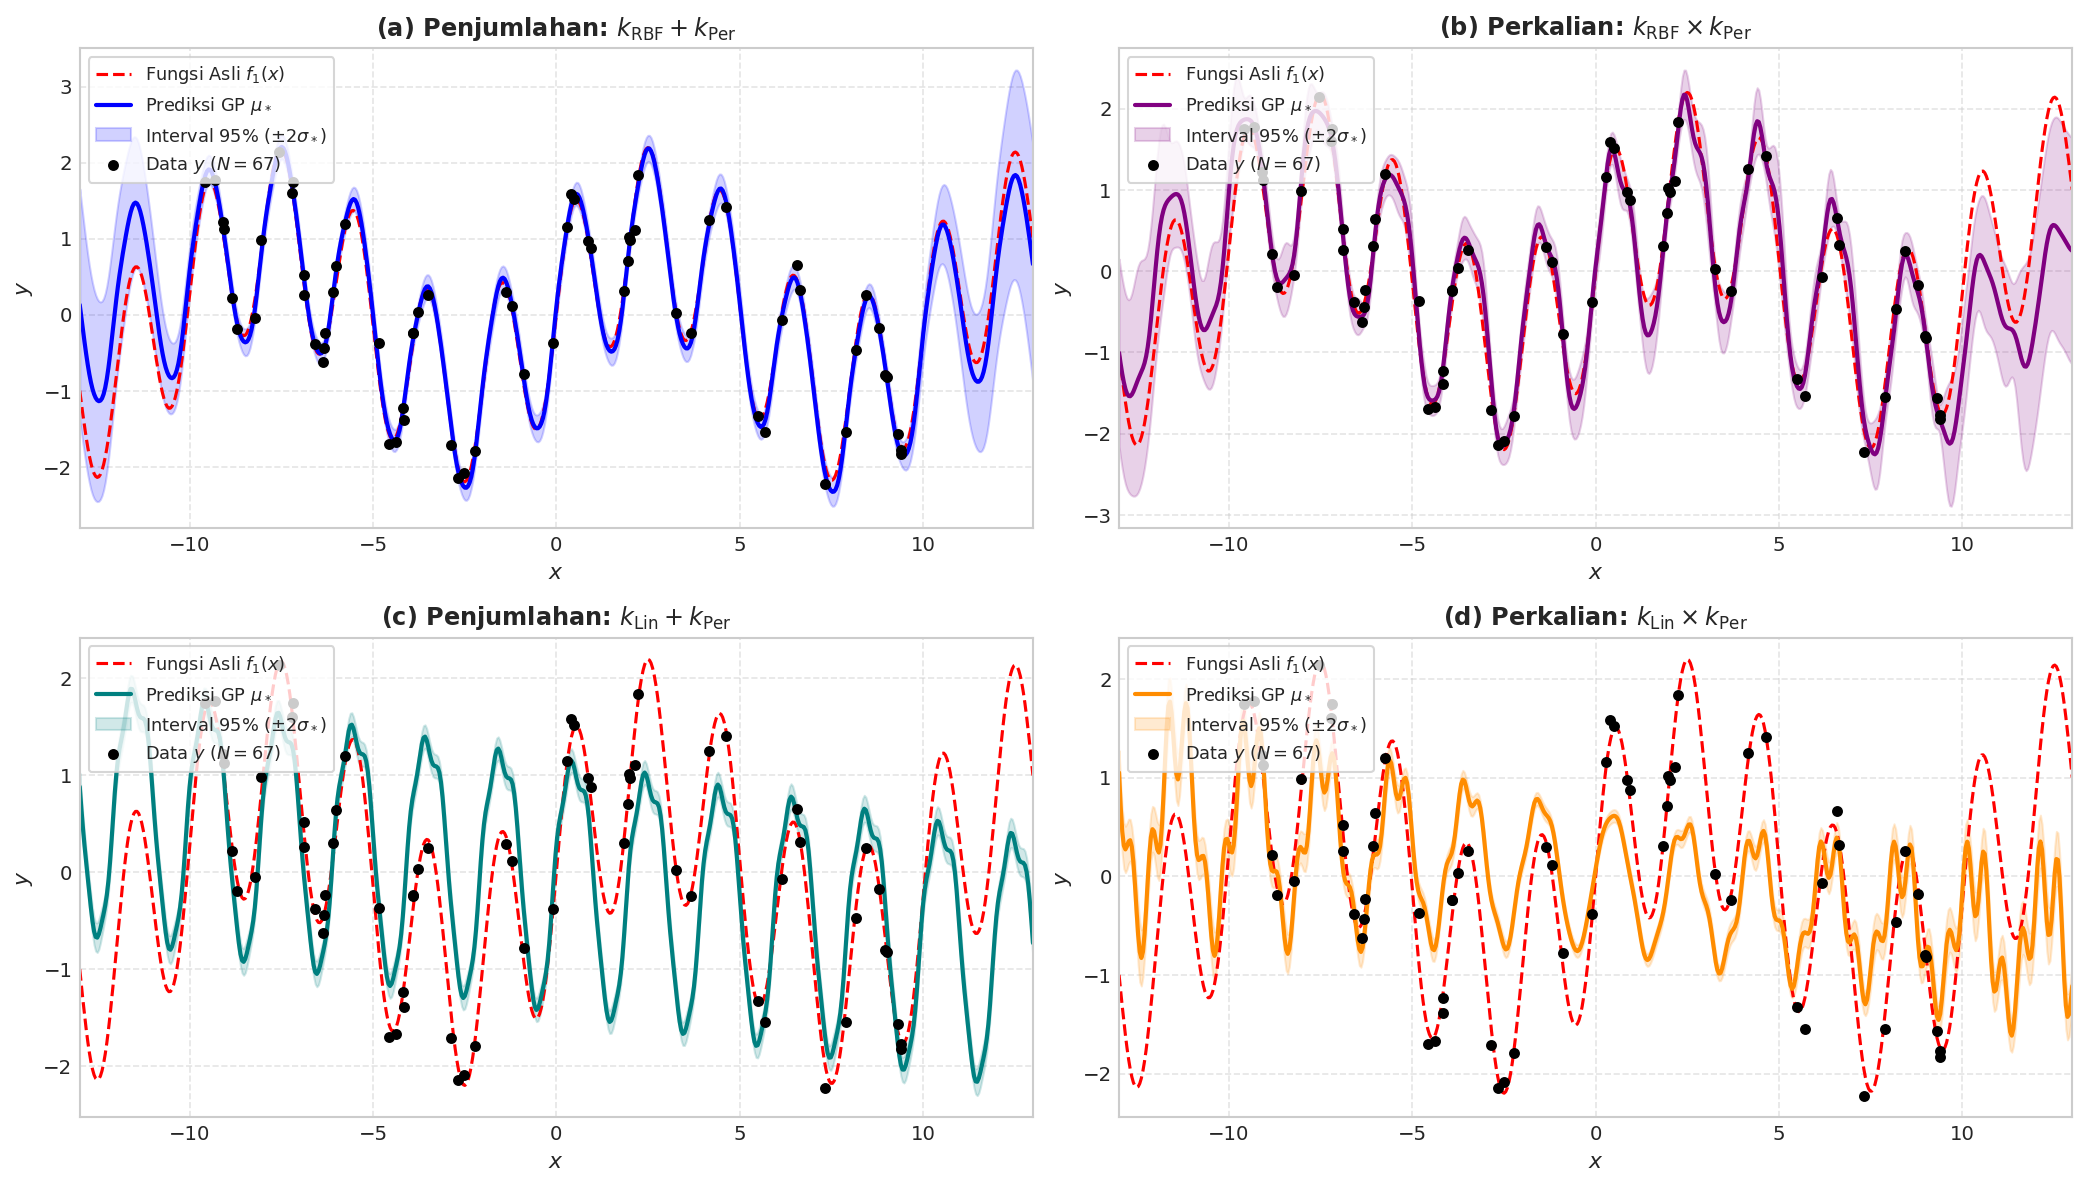

In [2]:
# =========================================================================
# 2. EKSPERIMEN 1: FUNGSI ASLI ADITIF (Superposisi Tren + Periodik)
# =========================================================================
np.random.seed(42)
N_points = 67
X_test = np.linspace(-13.0, 13.0, 600)[:, None]

# Data Latih Kasus 1
X1_train = np.sort(np.random.uniform(-10, 10, N_points))[:, None]
f1_true_train = np.sin(0.6 * X1_train) + 1.2 * np.sin(2.0 * np.pi * X1_train / period_val)
y1_train = f1_true_train + np.random.normal(0, 0.15, size=X1_train.shape)
f1_true_test = np.sin(0.6 * X_test) + 1.2 * np.sin(2.0 * np.pi * X_test / period_val)

mu1_rbf_sum, std1_rbf_sum = gp_predict(X1_train, y1_train, X_test, k_rbf_sum, sigma_n=0.15)
mu1_rbf_prod, std1_rbf_prod = gp_predict(X1_train, y1_train, X_test, k_rbf_prod, sigma_n=0.15)
mu1_lin_sum, std1_lin_sum = gp_predict(X1_train, y1_train, X_test, k_lin_sum, sigma_n=0.15)
mu1_lin_prod, std1_lin_prod = gp_predict(X1_train, y1_train, X_test, k_lin_prod, sigma_n=0.15)

fig1, axes1 = plt.subplots(2, 2, figsize=(14, 8), dpi=150)

# (a) RBF + Per
axes1[0, 0].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[0, 0].plot(X_test, mu1_rbf_sum, 'b-', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[0, 0].fill_between(X_test.flatten(), mu1_rbf_sum - 2*std1_rbf_sum, mu1_rbf_sum + 2*std1_rbf_sum, color='blue', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[0, 0].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[0, 0].set_title(r'(a) Penjumlahan: $k_{\mathrm{RBF}} + k_{\mathrm{Per}}$', fontweight='bold')
axes1[0, 0].set_xlabel('$x$'); axes1[0, 0].set_ylabel('$y$'); axes1[0, 0].set_xlim(-13.0, 13.0)
axes1[0, 0].legend(loc='upper left', frameon=True); axes1[0, 0].grid(True, linestyle='--', alpha=0.5)

# (b) RBF * Per
axes1[0, 1].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[0, 1].plot(X_test, mu1_rbf_prod, 'purple', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[0, 1].fill_between(X_test.flatten(), mu1_rbf_prod - 2*std1_rbf_prod, mu1_rbf_prod + 2*std1_rbf_prod, color='purple', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[0, 1].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[0, 1].set_title(r'(b) Perkalian: $k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes1[0, 1].set_xlabel('$x$'); axes1[0, 1].set_ylabel('$y$'); axes1[0, 1].set_xlim(-13.0, 13.0)
axes1[0, 1].legend(loc='upper left', frameon=True); axes1[0, 1].grid(True, linestyle='--', alpha=0.5)

# (c) Lin + Per
axes1[1, 0].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[1, 0].plot(X_test, mu1_lin_sum, 'teal', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[1, 0].fill_between(X_test.flatten(), mu1_lin_sum - 2*std1_lin_sum, mu1_lin_sum + 2*std1_lin_sum, color='teal', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[1, 0].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[1, 0].set_title(r'(c) Penjumlahan: $k_{\mathrm{Lin}} + k_{\mathrm{Per}}$', fontweight='bold')
axes1[1, 0].set_xlabel('$x$'); axes1[1, 0].set_ylabel('$y$'); axes1[1, 0].set_xlim(-13.0, 13.0)
axes1[1, 0].legend(loc='upper left', frameon=True); axes1[1, 0].grid(True, linestyle='--', alpha=0.5)

# (d) Lin * Per
axes1[1, 1].plot(X_test, f1_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_1(x)$')
axes1[1, 1].plot(X_test, mu1_lin_prod, 'darkorange', lw=2, label=r'Prediksi GP $\mu_*$')
axes1[1, 1].fill_between(X_test.flatten(), mu1_lin_prod - 2*std1_lin_prod, mu1_lin_prod + 2*std1_lin_prod, color='darkorange', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes1[1, 1].scatter(X1_train, y1_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes1[1, 1].set_title(r'(d) Perkalian: $k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes1[1, 1].set_xlabel('$x$'); axes1[1, 1].set_ylabel('$y$'); axes1[1, 1].set_xlim(-13.0, 13.0)
axes1[1, 1].legend(loc='upper left', frameon=True); axes1[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


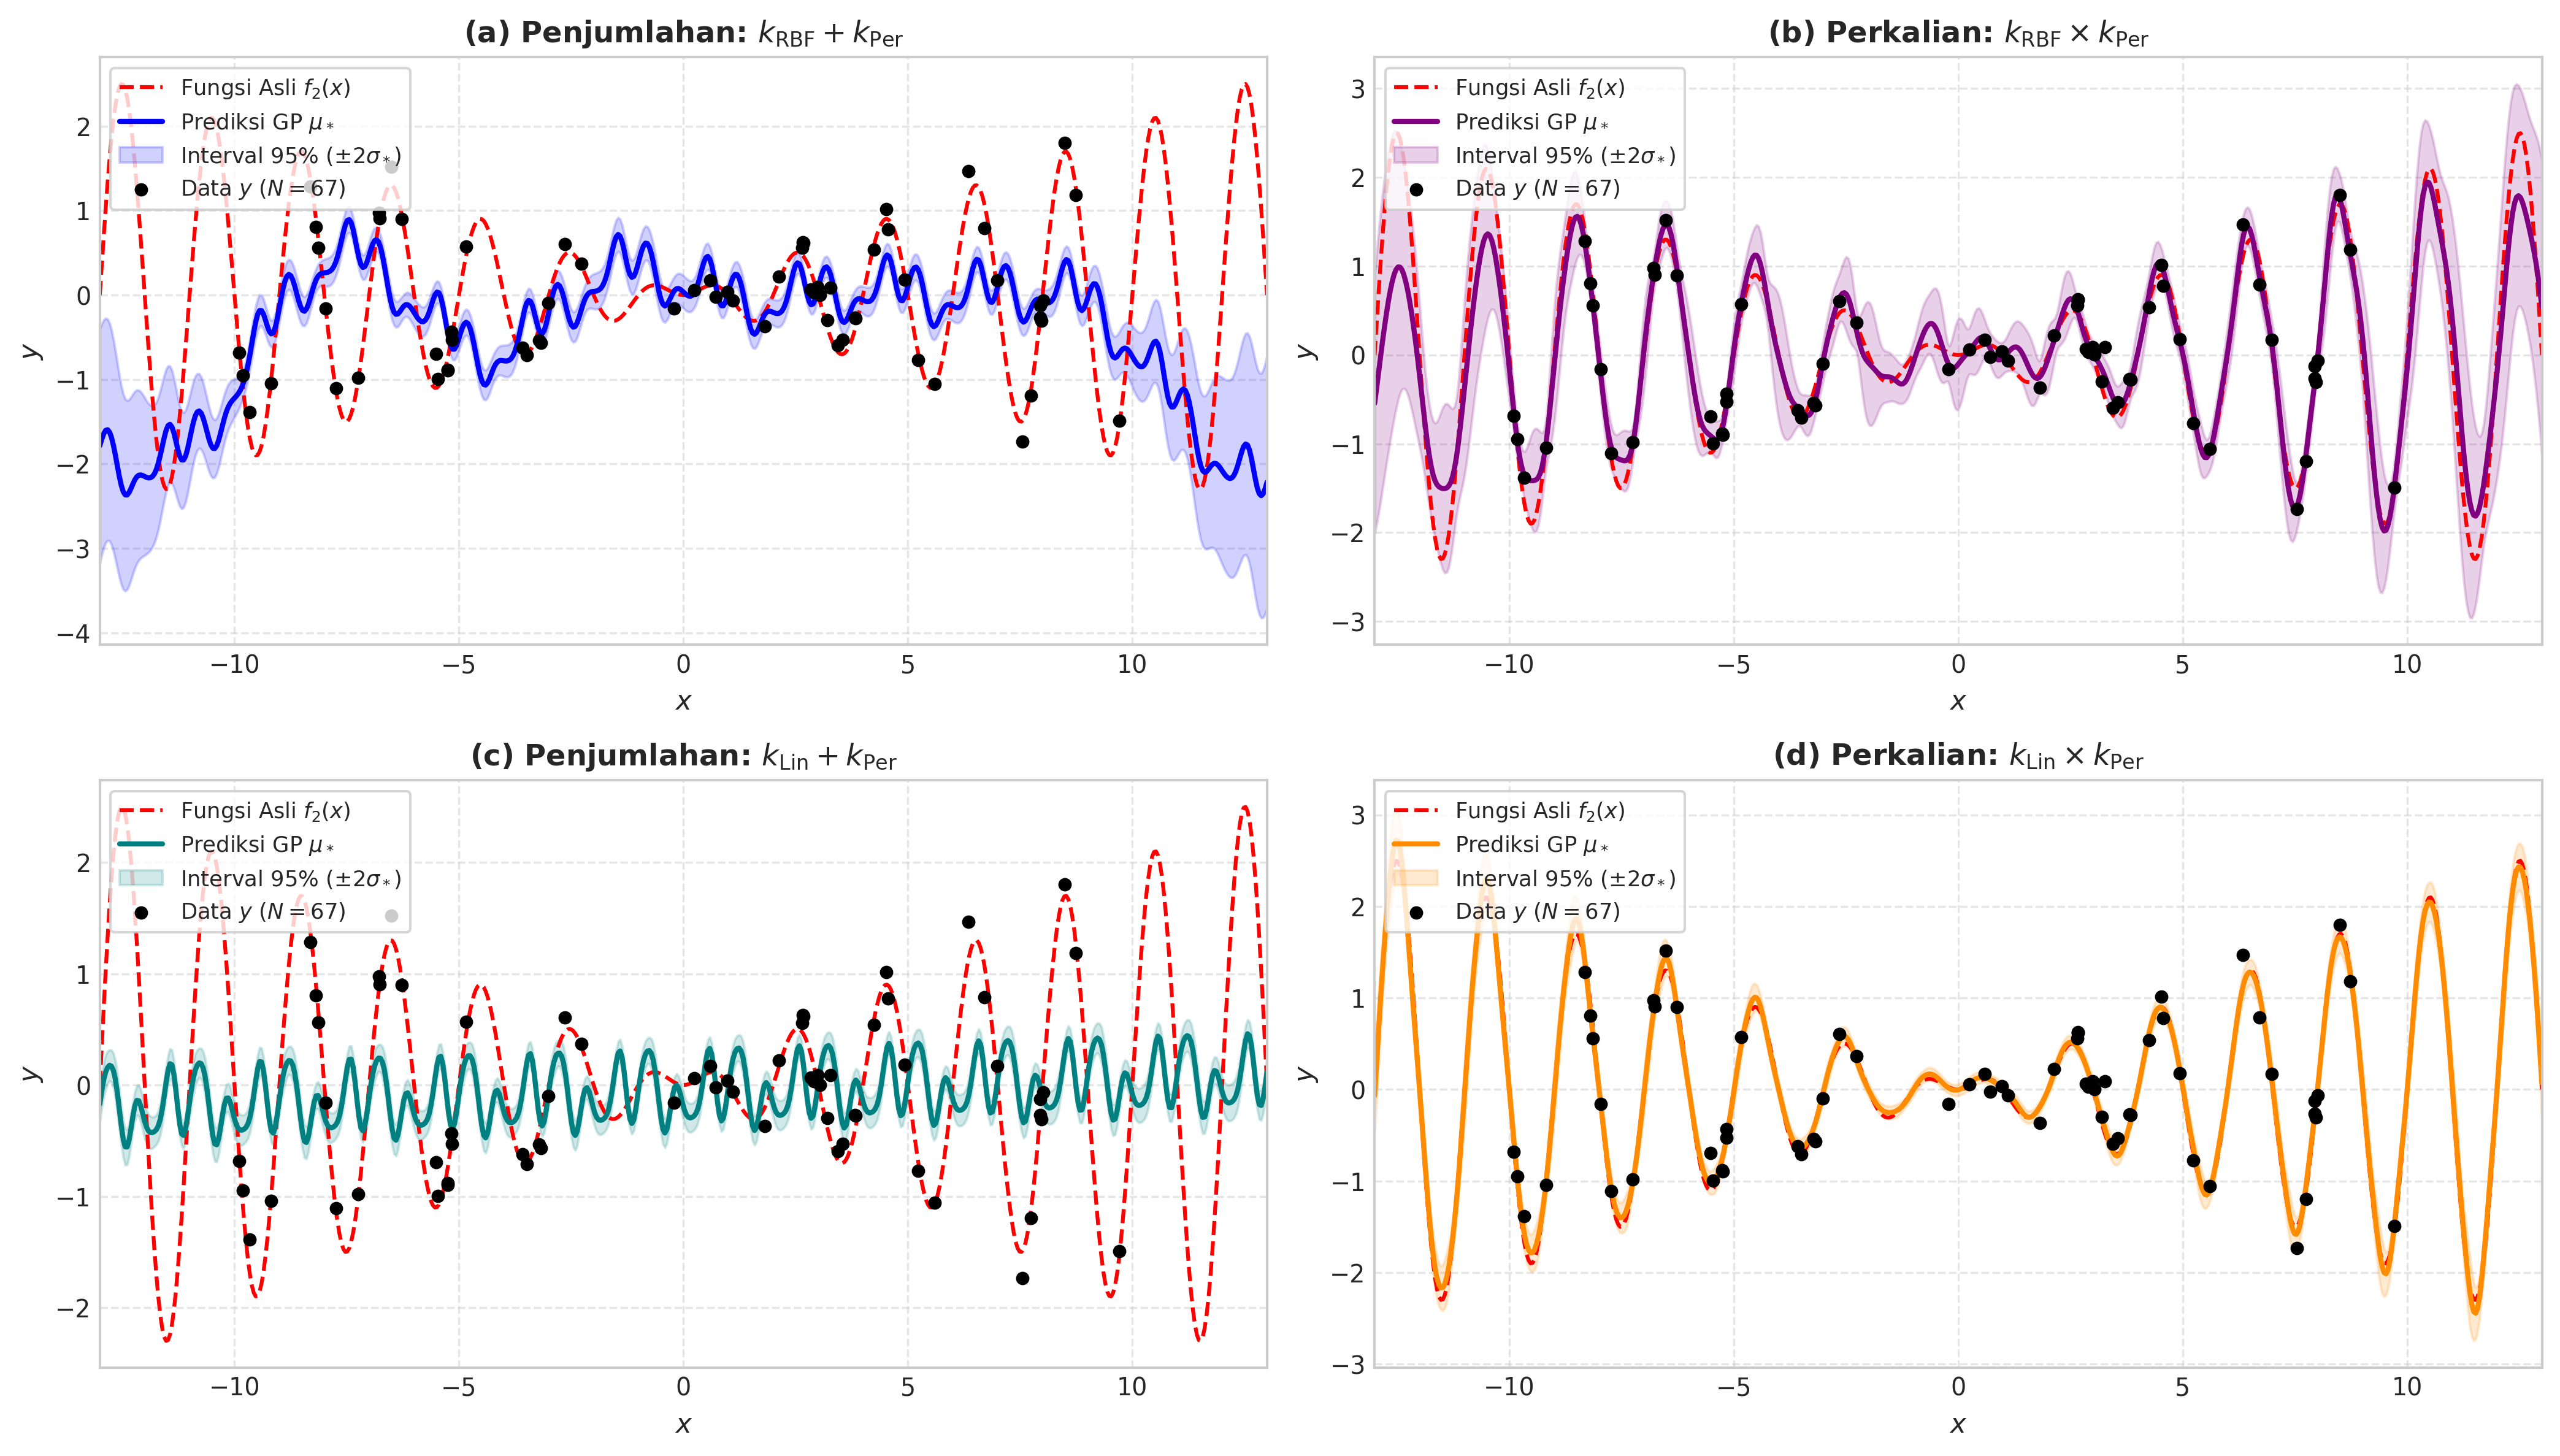

In [3]:
# =========================================================================
# 3. EKSPERIMEN 2: FUNGSI ASLI MULTIPLIKATIF (Modulasi Amplitudo)
# =========================================================================
# Data Latih Kasus 2
X2_train = np.sort(np.random.uniform(-10, 10, N_points))[:, None]
f2_true_train = 0.2 * X2_train * np.sin(2.0 * np.pi * X2_train / period_val)
y2_train = f2_true_train + np.random.normal(0, 0.15, size=X2_train.shape)
f2_true_test = 0.2 * X_test * np.sin(2.0 * np.pi * X_test / period_val)

mu2_rbf_sum, std2_rbf_sum = gp_predict(X2_train, y2_train, X_test, k_rbf_sum, sigma_n=0.15)
mu2_rbf_prod, std2_rbf_prod = gp_predict(X2_train, y2_train, X_test, k_rbf_prod, sigma_n=0.15)
mu2_lin_sum, std2_lin_sum = gp_predict(X2_train, y2_train, X_test, k_lin_sum, sigma_n=0.15)
mu2_lin_prod, std2_lin_prod = gp_predict(X2_train, y2_train, X_test, k_lin_prod, sigma_n=0.15)

fig2, axes2 = plt.subplots(2, 2, figsize=(14, 8), dpi=300)

# (a) RBF + Per
axes2[0, 0].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[0, 0].plot(X_test, mu2_rbf_sum, 'b-', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[0, 0].fill_between(X_test.flatten(), mu2_rbf_sum - 2*std2_rbf_sum, mu2_rbf_sum + 2*std2_rbf_sum, color='blue', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[0, 0].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[0, 0].set_title(r'(a) Penjumlahan: $k_{\mathrm{RBF}} + k_{\mathrm{Per}}$', fontweight='bold')
axes2[0, 0].set_xlabel('$x$'); axes2[0, 0].set_ylabel('$y$'); axes2[0, 0].set_xlim(-13.0, 13.0)
axes2[0, 0].legend(loc='upper left', frameon=True); axes2[0, 0].grid(True, linestyle='--', alpha=0.5)

# (b) RBF * Per
axes2[0, 1].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[0, 1].plot(X_test, mu2_rbf_prod, 'purple', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[0, 1].fill_between(X_test.flatten(), mu2_rbf_prod - 2*std2_rbf_prod, mu2_rbf_prod + 2*std2_rbf_prod, color='purple', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[0, 1].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[0, 1].set_title(r'(b) Perkalian: $k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes2[0, 1].set_xlabel('$x$'); axes2[0, 1].set_ylabel('$y$'); axes2[0, 1].set_xlim(-13.0, 13.0)
axes2[0, 1].legend(loc='upper left', frameon=True); axes2[0, 1].grid(True, linestyle='--', alpha=0.5)

# (c) Lin + Per
axes2[1, 0].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[1, 0].plot(X_test, mu2_lin_sum, 'teal', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[1, 0].fill_between(X_test.flatten(), mu2_lin_sum - 2*std2_lin_sum, mu2_lin_sum + 2*std2_lin_sum, color='teal', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[1, 0].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[1, 0].set_title(r'(c) Penjumlahan: $k_{\mathrm{Lin}} + k_{\mathrm{Per}}$', fontweight='bold')
axes2[1, 0].set_xlabel('$x$'); axes2[1, 0].set_ylabel('$y$'); axes2[1, 0].set_xlim(-13.0, 13.0)
axes2[1, 0].legend(loc='upper left', frameon=True); axes2[1, 0].grid(True, linestyle='--', alpha=0.5)

# (d) Lin * Per
axes2[1, 1].plot(X_test, f2_true_test, 'r--', lw=1.5, label='Fungsi Asli $f_2(x)$')
axes2[1, 1].plot(X_test, mu2_lin_prod, 'darkorange', lw=2, label=r'Prediksi GP $\mu_*$')
axes2[1, 1].fill_between(X_test.flatten(), mu2_lin_prod - 2*std2_lin_prod, mu2_lin_prod + 2*std2_lin_prod, color='darkorange', alpha=0.18, label=r'Interval $95\%$ ($\pm 2\sigma_*$)')
axes2[1, 1].scatter(X2_train, y2_train, c='black', s=18, zorder=5, label=f'Data $y$ ($N={N_points}$)')
axes2[1, 1].set_title(r'(d) Perkalian: $k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$', fontweight='bold')
axes2[1, 1].set_xlabel('$x$'); axes2[1, 1].set_ylabel('$y$'); axes2[1, 1].set_xlim(-13.0, 13.0)
axes2[1, 1].legend(loc='upper left', frameon=True); axes2[1, 1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


# ❓ Pertanyaan 9: Analisis Komparasi Operasi Kernel: Kapan Perkalian ($k_1 \times k_2$) Lebih Bagus dari Penjumlahan ($k_1 + k_2$) dan Sebaliknya?

> **Wah ternyata lebih bagus jika menggunakan operasi perkalian. Kapan hasil perkalian lebih bagus dari penjumlahan dan sebaliknya?**

---

## 💡 Jawaban 9: Analisis Komprehensif Desain & Kombinasi Kernel (*Kernel Engineering*)

Dalam pemodelan Gaussian Process (GP), pemilihan operasi antara **Penjumlahan ($+$)** dan **Perkalian ($\times$)** ditentukan oleh **struktur fisik, hubungan antar-proses laten, dan karakteristik variansi data** (*Rasmussen & Williams, 2006, Bab 4.2.4; Duvenaud, 2014*).

---

### 1. Intuisi Logika Aljabar Kernel: Operasi "OR" vs Operasi "AND"

| Dimensi Komparasi | Operasi Penjumlahan ($k_{\mathrm{sum}} = k_1 + k_2$) | Operasi Perkalian ($k_{\mathrm{prod}} = k_1 \times k_2$) |
| :--- | :--- | :--- |
| **Logika Konseptual** | **Operasi "OR" (Additive Decomposition)** | **Operasi "AND" (Interaction / Modulation)** |
| **Representasi Proses Laten** | Superposisi dua fungsi laten independen:<br>$f(\mathbf{x}) = f_1(\mathbf{x}) + f_2(\mathbf{x})$<br>dengan $f_1 \sim \mathcal{GP}(0, k_1)$ dan $f_2 \sim \mathcal{GP}(0, k_2)$ | Modulasi atau perkalian fungsi laten pada ruang fitur RKHS:<br>$f(\mathbf{x}) \sim \mathcal{GP}(0, k_1 \times k_2)$ |
| **Interpretasi Kovarians** | Dua titik $\mathbf{x}$ dan $\mathbf{x}'$ berkorelasi tinggi jika mereka mirip menurut kernel $k_1$ **ATAU** menurut kernel $k_2$. | Dua titik $\mathbf{x}$ dan $\mathbf{x}'$ hanya berkorelasi tinggi jika mereka mirip menurut kernel $k_1$ **DAN** menurut kernel $k_2$. |
| **Pengaruh Amplitudo** | Amplitudo masing-masing komponen bersifat **konstan/tetap** sepanjang domain. | Komponen pertama bertindak sebagai **amplop (*envelope*)** yang memodifikasi/memodulasi amplitudo komponen kedua. |

---

### 2. Kapan Operasi PERKALIAN ($k_1 \times k_2$) Lebih Bagus?

Operasi perkalian kernel unggul ketika data menunjukkan sifat **modulasi amplitudo**, **peluruhan korelasi jarak jauh (*locally periodic*)**, atau **interaksi silang antar-dimensi fitur**:

#### a. Modulasi Amplitudo Dinamis (*Dynamic Scale / Heteroscedasticity*)
* **Ciri Data**: Fluktuasi osilasi yang amplitudonya membesar atau menyusut seiring tren waktu/posisi (misal: $f(x) = 0{,}2 x \sin(\pi x)$ atau getaran mesin yang amplitudonya membesar saat kecepatan putaran naik).
* **Kernel Terbaik**: $k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$ atau $k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$.
* **Mengapa Menang**: Kernel linier $k_{\mathrm{Lin}}$ mengalikan kovarians periodik, sehingga variansi lokal membesar secara proporsional terhadap jarak dari titik asal ($x$). Penjumlahan ($k_{\mathrm{Lin}} + k_{\mathrm{Per}}$) gagal total karena hanya memiringkan garis tengah tanpa bisa memperbesar ayunan gelombang.

#### b. Osilasi Lokal yang Meredup (*Locally Periodic / Damped Waves*)
* **Ciri Data**: Pola periodik yang bentuk gelombangnya perlahan berubah atau meredup seiring jarak (misal: riak gelombang air, siklus ekonomi makro, fluktuasi cuaca musiman yang bervariasi antar-dekade).
* **Kernel Terbaik**: $k_{\mathrm{RBF}} \times k_{\mathrm{Per}}$.
* **Mengapa Menang**: Karena $k_{\mathrm{RBF}}(\mathbf{x}, \mathbf{x}') \to 0$ saat $|\mathbf{x} - \mathbf{x}'| \to \infty$, perkalian ini memastikan bahwa korelasi antar-titik periodik hanya berlaku secara lokal dan meluruh pada jarak jauh.

#### c. Interaksi Antar-Dimensi Fitur (Fitur Spasio-Temporal)
* **Ciri Data**: Data multi-dimensi di mana pengaruh satu fitur bergantung pada fitur lainnya (misal: suhu udara yang bergantung pada Koordinat Lokasi $\mathbf{x}$ dan Waktu Musim $t$).
* **Kernel Terbaik**: $k_{\mathrm{space}}(\mathbf{x}, \mathbf{x}') \times k_{\mathrm{time}}(t, t')$.
* **Mengapa Menang**: Menerapkan aturan "AND": Titik $A$ dan $B$ hanya memiliki korelasi suhu tinggi jika mereka berada di lokasi berdekatan **DAN** diukur pada waktu musim yang sama.

---

### 3. Kapan Operasi PENJUMLAHAN ($k_1 + k_2$) Lebih Bagus?

Operasi penjumlahan kernel unggul ketika data tersusun dari **superposisi komponen-komponen independen** yang bekerja pada skala atau karakteristik yang berbeda:

#### a. Penguraian Tren Global + Fluktuasi Musiman Stabil (*Additive Time-Series Decomposition*)
* **Ciri Data**: Data deret waktu dengan tren jangka panjang yang bertumpuk dengan pola musiman yang amplitudonya stabil (misal: Konsentrasi gas $\text{CO}_2$ atmosfer di Mauna Loa / *Keeling Curve*).
  * Tren kenaikan $\text{CO}_2$ akibat emisi industri terus meningkat.
  * Fluktuasi musiman tahunan akibat fotosintesis tanaman selalu stabil di kisaran $\pm 3\text{ ppm}$ sepanjang 60 tahun terakhir.
* **Kernel Terbaik**: $k_{\mathrm{RBF}}(\text{tren lambat}) + k_{\mathrm{Per}}(\text{musiman}) + k_{\mathrm{Mat\acute{e}rn}}(\text{anomali menengah})$.
* **Mengapa Menang**: Operasi penjumlahan memisahkan komponen tren dan musiman secara aditif. Jika dipaksakan perkalian ($k_{\mathrm{Lin}} \times k_{\mathrm{Per}}$), model akan keliru memprediksi bahwa variasi fotosintesis tanaman membesar berlipat ganda seiring kenaikan emisi $\text{CO}_2$.

#### b. Struktur Multi-Skala (*Multi-Scale Variations*)
* **Ciri Data**: Sinyal yang memiliki korelasi jarak jauh (tren lambat dengan $\ell_1$ besar) sekaligus riak fluktuasi lokal yang cepat ($\ell_2$ kecil).
* **Kernel Terbaik**: $k_{\mathrm{RBF}}^{(\text{long})} + k_{\mathrm{RBF}}^{(\text{short})}$.
* **Mengapa Menang**: Memungkinkan GP menangkap variasi frekuensi rendah dan frekuensi tinggi secara simultan tanpa meredam salah satunya.

#### c. Ekstrapolasi Periodik Murni Tanpa Peluruhan
* **Ciri Data**: Sistem fisika dengan osilasi abadi (misal: orbit planet atau bandul ideal) yang bertumpuk di atas tren pergeseran koordinat.
* **Mengapa Menang**: $k_{\mathrm{sum}}$ mempertahankan gelombang periodik tak hingga pada daerah ekstrapolasi ($|x| > 10$), sedangkan $k_{\mathrm{prod}}$ dengan RBF akan mematikan gelombang menuju nol.

---

### 4. Diagram Alur Panduan Pemilihan Kernel (*Decision Guide*)

```
                         Struktur Hubungan Antar-Pola pada Data
                                          │
                   ┌──────────────────────┴──────────────────────┐
                   ▼                                             ▼
       [ Pola Saling Tergantung / Modulasi ]          [ Pola Independen / Bertumpuk ]
                   │                                             │
         ( OPERASI PERKALIAN: × )                       ( OPERASI PENJUMLAHAN: + )
                   │                                             │
      ┌────────────┴────────────┐                   ┌────────────┴────────────┐
      ▼                         ▼                   ▼                         ▼
Amplitudo membesar       Amplitudo meluruh   Tren Global + Musiman     Variasi Multi-Skala
seiring tren linier      secara lokal        dengan amplitudo tetap    (Panjang + Pendek)
      │                         │                   │                         │
      ▼                         ▼                   ▼                         ▼
[ k_Lin × k_Per ]        [ k_RBF × k_Per ]   [ k_RBF + k_Per ]         [ k_RBF + k_RBF ]
```


# ❓ Pertanyaan 10: Mengapa Rumus Kernel Periodik di Dokumen/PDF Berbeda dengan Buku Rasmussen & Williams Halaman 92 Persamaan (4.31)?

> **Kenapa rumus kernel periodik di pdf berbeda dengan buku rasmussen halaman 92 (4.31)?**

---

## 💡 Jawaban 10: Perbandingan Formulasi Kernel Periodik

Perbedaan antara rumus kernel periodik pada **Buku Rasmussen & Williams (2006) hlm. 92 Persamaan (4.31)** dengan **Dokumen PDF / implementasi praktis** terletak pada **generalisasi periode ($p$)** dan **parameter variansi output ($\sigma_p^2$)**.

---

### 1. Perbandingan Formula Matematis

* **Buku Rasmussen & Williams (2006) hlm. 92, Persamaan (4.31):**
  $$k(x, x') = \exp\left( -\frac{2\sin^2\left(\frac{x - x'}{2}\right)}{\ell^2} \right)$$

* **Dokumen PDF / Implementasi Pustaka GP (GPy, GPflow, Scikit-learn):**
  $$k_{\mathrm{Per}}(x, x') = \sigma_p^2 \exp\left( -\frac{2\sin^2\left(\frac{\pi |x - x'|}{p}\right)}{\ell_{\mathrm{Per}}^2} \right)$$

---

### 2. Tiga Perbedaan Utama & Penjelasannya

#### A. Periode Arbitrer ($p$) vs Periode Standar ($2\pi$)
1. **Penurunan di Buku Rasmussen (hlm. 92):**
   Rasmussen mengonstruksi kernel periodik 1D dengan memetakan input $x \in \mathbb{R}$ ke ruang 2D pada lingkaran satuan (*unit circle*):
   $$\mathbf{u}(x) = \begin{bmatrix} \cos(x) \\ \sin(x) \end{bmatrix}$$
   Karena fungsi trigonometri $\cos(x)$ dan $\sin(x)$ memiliki periode alami $2\pi$, pemetaan ini secara implisit **mengasumsikan periode bernilai tetap $p = 2\pi$**.
   
   Jarak Euclidean kuadrat di ruang lingkaran $\mathbf{u}$ adalah:
   $$\begin{aligned}
   \|\mathbf{u}(x) - \mathbf{u}(x')\|^2 &= (\cos x - \cos x')^2 + (\sin x - \sin x')^2 \\
   &= (\cos^2 x + \sin^2 x) + (\cos^2 x' + \sin^2 x') - 2(\cos x \cos x' + \sin x \sin x') \\
   &= 1 + 1 - 2\cos(x - x') \\
   &= 2 - 2\cos(x - x') \\
   &= 4 \sin^2\left(\frac{x - x'}{2}\right)
   \end{aligned}$$
   
   Ketika jarak kuadrat ini dimasukkan ke dalam fungsi kovariansi *Squared Exponential* (RBF) 2D $k(\mathbf{u}, \mathbf{u}') = \exp\left(-\frac{\|\mathbf{u} - \mathbf{u}'\|^2}{2\ell^2}\right)$, diperoleh:
   $$k(x, x') = \exp\left( -\frac{4\sin^2\left(\frac{x - x'}{2}\right)}{2\ell^2} \right) = \exp\left( -\frac{2\sin^2\left(\frac{x - x'}{2}\right)}{\ell^2} \right) \quad \text{(Persamaan 4.31)}$$

2. **Generalisasi pada Dokumen PDF:**
   Dalam aplikasi nyata, fenomena berulang memiliki panjang periode sembarang $p > 0$ (misalnya $p = 2{,}0$ pada eksperimen bimbingan, $p = 12$ untuk siklus bulanan, $p = 24$ untuk siklus jam harian).
   Untuk mengakomodasi periode $p$, domain input di-*rescale* menjadi $\frac{2\pi x}{p}$, sehingga pemetaannya menjadi:
   $$\mathbf{u}(x) = \begin{bmatrix} \cos\left(\frac{2\pi x}{p}\right) \\ \sin\left(\frac{2\pi x}{p}\right) \end{bmatrix}$$
   Jarak kuadratnya menjadi:
   $$\|\mathbf{u}(x) - \mathbf{u}(x')\|^2 = 4 \sin^2\left( \frac{\frac{2\pi x}{p} - \frac{2\pi x'}{p}}{2} \right) = 4 \sin^2\left( \frac{\pi (x - x')}{p} \right)$$
   
   Jika disubstitusikan $p = 2\pi$:
   $$\frac{\pi (x - x')}{2\pi} = \frac{x - x'}{2}$$
   **Artinya, Persamaan (4.31) di buku Rasmussen adalah kasus khusus ketika $p = 2\pi$, sedangkan rumus di PDF adalah bentuk umum (generalisasi) untuk sembarang periode $p$.**

---

#### B. Parameter Variansi Sinyal Output ($\sigma_p^2$)
* **Buku Rasmussen (Eq. 4.31):** Ditulis dalam bentuk dasar (*normalized/unit variance*), di mana amplitudo kovariansi maksimum diatur bernilai 1.
* **Dokumen PDF:** Menambahkan hiperparameter $\sigma_p^2 > 0$ sebagai pengali variansi sinyal output (*signal variance*), agar GP dapat memodelkan skala vertikal data yang amplitudonya tidak harus bernilai 1.

---

#### C. Tanda Nilai Mutlak $|x - x'|$ vs $(x - x')$
Karena fungsi sinus memiliki sifat ganjil $\sin(-\theta) = -\sin(\theta)$, maka saat dikuadratkan:
$$\sin^2(-\theta) = [-\sin(\theta)]^2 = \sin^2(\theta) = \sin^2(|\theta|)$$
Oleh karena itu:
$$\sin^2\left(\frac{\pi |x - x'|}{p}\right) \equiv \sin^2\left(\frac{\pi (x - x')}{p}\right)$$
Kedua notasi menghasilkan nilai yang **persis sama secara aljabar dan numerik**. Notasi $|x - x'|$ digunakan di PDF untuk menegaskan bahwa kernel periodik ini tergolong kernel berbasis jarak stasioner (*distance-based stationary metric*).

---

### 3. Tabel Ringkasan Komparasi

| Komponen | Buku Rasmussen (2006) Eq. (4.31) | Dokumen PDF / Praktis | Keterangan |
| :--- | :--- | :--- | :--- |
| **Periode ($p$)** | $p = 2\pi$ (implisit/tetap) | $p > 0$ (eksplisit & fleksibel) | PDF merupakan generalisasi untuk sembarang periode. |
| **Variansi Output ($\sigma^2$)** | Tersirat 1 (dasar) | $\sigma_p^2$ (hiperparameter) | Mengatur skala amplitudo vertikal data. |
| **Argumen Sinus** | $\sin\left(\frac{x - x'}{2}\right)$ | $\sin\left(\frac{\pi \|x - x'\|}{p}\right)$ | Identik ketika $p = 2\pi$. |
| **Sifat Nilai Mutlak** | $(x - x')$ | $\|x - x'\|$ | Nilai kuadrat $\sin^2(\cdot)$ selalu identik. |

$$\underbrace{\sigma_p^2 \exp\left( -\frac{2\sin^2\left(\frac{\pi |x - x'|}{p}\right)}{\ell_{\mathrm{Per}}^2} \right)}_{\text{Rumus PDF}} \xrightarrow{p = 2\pi, \; \sigma_p^2 = 1} \underbrace{\exp\left( -\frac{2\sin^2\left(\frac{x - x'}{2}\right)}{\ell^2} \right)}_{\text{Rasmussen (4.31)}}$$


# ❓ Pertanyaan 11: Daftar Package Python dan Fungsi-Fungsinya untuk Gaussian Process (GP) & Deep Gaussian Process (DGP)

> **Saya ingin lanjut mengerjakan section 3. Saya ingin menambahkan package2 beserta fungsi2nya yang mungkin akan untuk GP. Tolong list dulu di coret.ipynb. Nanti saya akan memilih mana yang akan dimasukkan ke section 3.**

---

## 💡 Jawaban 11: Katalog Package Python untuk Gaussian Processes

Berikut adalah kurasi dan klasifikasi lengkap mengenai pustaka (*packages/libraries*) Python yang umum dan standar digunakan untuk komputasi **Gaussian Process Regression/Classification**, **Sparse GP**, hingga **Deep Gaussian Process (DGP)**, beserta modul, kelas, dan fungsi-fungsi utamanya.

---

### 1. Ringkasan & Taksonomi Package GP

| No | Package | *Backend Framework* | Dukungan GPU | Skalabilitas & Fitur Utama | Tingkat Relevansi untuk TA (DGP / Image) |
|:---:|:---|:---|:---:|:---|:---:|
| **1** | **GPyTorch** | PyTorch | ✅ Penuh (CUDA) | Exact GP, Sparse/Variational GP, Deep GP, Kernel Interfacing, Linear Operator | ⭐⭐⭐⭐⭐ (Sangat Tinggi / Utama) |
| **2** | **GPflow** | TensorFlow 2 / TFP | ✅ Penuh (GPU/TPU) | Modern Variational GP (SVGP), MCMC, Interoperabilitas TensorFlow | ⭐⭐⭐⭐ (Tinggi) |
| **3** | **GPy** | NumPy / SciPy / Cython | ❌ (CPU Only) | Standar klasik Sheffield ML, implementasi algoritma murni, fondasi DeepGP | ⭐⭐⭐ (Menengah / Referensi) |
| **4** | **Scikit-Learn** | NumPy / SciPy | ❌ (CPU Only) | Implementasi standar sederhana, prototyping cepat, baseline GPR/GPC | ⭐⭐⭐ (Dasar / Baseline) |
| **5** | **Pyro (`pyro.contrib.gp`)** | PyTorch | ✅ Penuh (CUDA) | Probabilistic Programming, Bayesian Deep Learning, Variational Inference | ⭐⭐⭐⭐ (Tinggi) |
| **6** | **GPJax** | JAX | ✅ Penuh (GPU/TPU) | Auto-differentiation (`jax.grad`), JIT Compilation (`jax.jit`), Vmap | ⭐⭐⭐ (Modern / Riset Alternatif) |

---

### 2. Rincian Modul dan Fungsi Utama Tiap Package

---

#### 📦 A. GPyTorch (`gpytorch`) — *Rekomendasi Utama untuk Deep GP & PyTorch*
Pustaka mutakhir berbasis PyTorch yang dirancang untuk komputasi GP berkecepatan tinggi dengan akselerasi GPU, dekomposisi matriks Krylov (BBMM / KeOps), dan mendukung arsitektur Deep Gaussian Process berlapis (*stacked layers*).

1. **Modul Model (`gpytorch.models`)**:
   - `gpytorch.models.ExactGP`: Kelas dasar untuk regresi GP standar dengan observasi Gaussian (menggunakan dekomposisi Cholesky / Lanczos).
   - `gpytorch.models.ApproximateGP`: Kelas dasar untuk *Variational Gaussian Process* (VGP/SVGP) pada data skala besar atau data non-Gaussian.
   - `gpytorch.models.deep_gps.DeepGP`: Kelas khusus untuk menyusun arsitektur *Deep Gaussian Process* multi-layer.

2. **Modul Mean Functions (`gpytorch.means`)**:
   - `ConstantMean()`: $\mu(x) = c$ (prior mean konstan).
   - `LinearMean(input_size)`: $\mu(x) = \mathbf{w}^T \mathbf{x} + b$ (prior mean linear).
   - `ZeroMean()`: $\mu(x) = 0$.

3. **Modul Kernel / Covariance Functions (`gpytorch.kernels`)**:
   - `RBFKernel(ard_num_dims)`: Kernel Radial Basis Function / Gaussian.
   - `PeriodicKernel(period_length)`: Kernel periodik untuk data bersiklus.
   - `LinearKernel()`: Kernel linear untuk pemodelan tren garis lurus.
   - `MaternKernel(nu=1.5 / 2.5)`: Kernel Matérn untuk fungsi yang kurang halus (*rougher paths*).
   - `SpectralMixtureKernel(num_mixtures)`: Kernel kombinasi spektral untuk pola frekuensi kompleks.
   - `ScaleKernel(base_kernel)`: Menambahkan faktor skala output $\sigma_f^2$ di depan kernel dasar: $\sigma_f^2 \cdot k(\mathbf{x}, \mathbf{x}')$.
   - `AdditiveKernel(k1, k2)` / Operator `k1 + k2`: Operasi penjumlahan kernel.
   - `ProductKernel(k1, k2)` / Operator `k1 * k2`: Operasi perkalian kernel.
   - `GridKernel` / `GridInterpolationKernel` (KISS-GP): Akselerasi GP terstruktur untuk citra/grid 2D.

4. **Modul Likelihood (`gpytorch.likelihoods`)**:
   - `GaussianLikelihood()`: Likelihood Gaussian standar $y = f(x) + \varepsilon, \; \varepsilon \sim \mathcal{N}(0, \sigma_n^2)$.
   - `BernoulliLikelihood()`: Likelihood untuk klasifikasi biner.
   - `SoftmaxLikelihood(num_classes)`: Likelihood untuk klasifikasi multi-kelas (relevan untuk segmentasi citra).

5. **Modul Loss & Marginal Likelihood (`gpytorch.mlls`)**:
   - `ExactMarginalLogLikelihood(likelihood, model)`: Menghitung $\log p(\mathbf{y}|X, \boldsymbol{\theta})$ eksak.
   - `VariationalELBO(likelihood, model, num_data)`: Menghitung *Evidence Lower Bound* (ELBO) pada Sparse/Variational GP.
   - `DeepApproximateMLL(mll)`: Menghitung marginal log likelihood objektif untuk Deep GP.

6. **Modul Variational Distribution & Strategy (`gpytorch.variational`)**:
   - `CholeskyVariationalDistribution(num_inducing_points)`: Distribusi aproksimasi variasional $q(\mathbf{u})$.
   - `VariationalStrategy(model, inducing_points, ...)`: Strategi penempatan *inducing points* $\mathbf{u}$.

---

#### 📦 B. GPflow (`gpflow`) — *Standar Industri Berbasis TensorFlow*
Pustaka open-source buatan Cambridge/Imperial College berbasis TensorFlow yang mengimplementasikan metode aproksimasi variasional modern (Hensman et al.).

1. **Modul Model (`gpflow.models`)**:
   - `gpflow.models.GPR(data=(X, y), kernel=k, mean_function=m)`: Gaussian Process Regression eksak.
   - `gpflow.models.SGPR(data, kernel, inducing_variable)`: Sparse Gaussian Process Regression (menggunakan subset *inducing points*).
   - `gpflow.models.SVGP(kernel, likelihood, inducing_variable)`: *Sparse Variational GP* untuk big data dan klasifikasi non-Gaussian dengan optimasi mini-batch.
   - `gpflow.models.VGP(data, kernel, likelihood)`: Variational GP tanpa *inducing points*.

2. **Modul Kernel (`gpflow.kernels`)**:
   - `gpflow.kernels.SquaredExponential(variance, lengthscales)`: Kernel RBF.
   - `gpflow.kernels.Periodic(base_kernel, period)`: Kernel Periodik.
   - `gpflow.kernels.Linear(variance)`: Kernel Linear.
   - `gpflow.kernels.Matern32()`, `gpflow.kernels.Matern52()`.
   - `gpflow.kernels.White(variance)`: Kernel noise $\sigma_n^2 I$.
   - Operator `k1 + k2` (`Sum`) dan `k1 * k2` (`Product`).

3. **Modul Likelihood (`gpflow.likelihoods`)**:
   - `gpflow.likelihoods.Gaussian(variance)`
   - `gpflow.likelihoods.Bernoulli()`, `gpflow.likelihoods.MultiClass(num_classes)`
   - `gpflow.likelihoods.Robustmax(num_classes)`

4. **Modul Optimasi (`gpflow.optimizers`)**:
   - `gpflow.optimizers.Scipy()`: Membungkus L-BFGS-B dari SciPy untuk optimasi parameter deterministik.
   - `tf.optimizers.Adam(learning_rate)`: Penggunaan optimizer Adam bawaan TensorFlow untuk mini-batch SVGP.

---

#### 📦 C. GPy (`GPy`) — *Pustaka Fondasi & Referensi Teoretis Sheffield ML*
Dikembangkan oleh Sheffield Machine Learning Group (Neil D. Lawrence), merupakan salah satu pustaka GP paling lengkap secara teori statistik, namun berbasis CPU (NumPy).

1. **Model Utama (`GPy.models`)**:
   - `GPy.models.GPRegression(X, Y, kernel)`: Regresi GP standar.
   - `GPy.models.SparseGPRegression(X, Y, Z, kernel)`: Regresi GP sparse dengan inducing inputs $Z$.
   - `GPy.models.GPClassification(X, Y, kernel)`: Klasifikasi dengan Laplace / EP.
   - `GPy.models.BayesianGPLVM(Y, input_dim, ...)`: *Gaussian Process Latent Variable Model*.

2. **Kernel (`GPy.kern`)**:
   - `GPy.kern.RBF(input_dim, variance, lengthscale)`
   - `GPy.kern.StdPeriodic(input_dim, variance, period, lengthscale)`
   - `GPy.kern.Linear(input_dim, variances)`
   - `GPy.kern.Add([k1, k2])`, `GPy.kern.Prod([k1, k2])`

3. **Metode Optimasi**:
   - `model.optimize(optimizer='lbfgs' / 'scg', max_iters=1000)`: Optimasi parameter marginal likelihood bawaan.
   - `model.plot()`: Visualisasi kurva mean, interval kepercayaan, dan titik data secara instan.

---

#### 📦 D. Scikit-Learn (`sklearn.gaussian_process`) — *Baseline & Pustaka Ringan*
Modul GP bawaan dari library machine learning terpopuler di Python, cocok untuk eksperimen perbandingan (*baseline comparison*).

1. **Kelas Estimator**:
   - `GaussianProcessRegressor(kernel=..., alpha=1e-10, optimizer='fmin_l_bfgs_b', n_restarts_optimizer=5)`:
     - Fungsi `.fit(X, y)`: Melakukan pelatihan / optimasi hiperparameter kernel via L-BFGS.
     - Fungsi `.predict(X_test, return_std=True / return_cov=True)`: Menghasilkan prediksi posterior mean $\mu_*$ dan standar deviasi $\sigma_*$.
     - Fungsi `.log_marginal_likelihood(theta)`: Menghitung nilai objektif LML.
   - `GaussianProcessClassifier(kernel=..., optimizer='fmin_l_bfgs_b')`: Klasifikasi biner/multikelas berbasis aproksimasi Laplace.

2. **Kernel (`sklearn.gaussian_process.kernels`)**:
   - `RBF(length_scale=1.0, length_scale_bounds=(1e-2, 1e2))`
   - `ExpSineSquared(length_scale=1.0, periodicity=1.0, periodicity_bounds=...)`: Kernel Periodik.
   - `DotProduct(sigma_0=1.0)`: Kernel Linear homogen / non-homogen.
   - `Matern(length_scale=1.0, nu=1.5)`
   - `WhiteKernel(noise_level=1.0)`: Estimasi noise $\sigma_n^2$.
   - `ConstantKernel(constant_value=1.0)`: Faktor skala variansi output $\sigma_f^2$.
   - Operator `+` (Sum) dan `*` (Product).

---

#### 📦 E. Pyro (`pyro.contrib.gp`) — *Probabilistic Programming & Bayesian Deep GP*
Ekstensi Gaussian Process pada bahasa pemrograman probabilistik Pyro (berbasis PyTorch), sangat cocok jika ingin menggabungkan GP dengan *Variational Autoencoders* (VAE) atau arsitektur Bayesian Deep Learning untuk citra.

1. **Model (`pyro.contrib.gp.models`)**:
   - `GPRegression(X, y, kernel, jitter=1e-6)`
   - `VariationalGP(X, y, kernel, likelihood, ...)`
   - `VariationalSparseGP(X, y, kernel, Xu, likelihood, ...)`

2. **Likelihood & Inferensi**:
   - Likelihood: `Gaussian`, `Binary`, `MultiClass`, `Poisson`
   - Inferensi: `pyro.infer.SVI` (*Stochastic Variational Inference*) dengan `pyro.infer.Trace_ELBO()`.

---

#### 📦 F. GPJax (`gpjax`) — *Framework Generasi Baru Berbasis JAX*
Pustaka fungsional modern yang memanfaatkan ekosistem Google JAX untuk kompilasi XLA berkecepatan tinggi dan diferensiasi otomatis tingkat lanjut.

1. **Objek & Fungsi Utama**:
   - `gpjax.gps.Prior(mean_function, kernel)`: Mendefinisikan prior Gaussian Process.
   - `prior * likelihood`: Mengkonstruksi posterior GP.
   - `gpjax.objectives.ConjugateMLL` / `NonConjugateMLL`: Menghitung marginal log-likelihood.
   - `gpjax.fit(model, objective, train_data, optax_optimizer)`: Pelatihan dengan library optimasi `optax` (Adam, SGD, dll.).
   - `gpjax.kernels`: `RBF`, `Periodic`, `Linear`, `Matern32`, `Matern52`.

---

### 3. Rekomendasi Pemilihan Package untuk Section 3 Dokumen Bimbingan

Untuk kebutuhan **Section 3** pada dokumen [kredit_bimbingan_05.tex](file:///c:/Users/MyBook%20Z%20Series/Desktop/TA/04_dokumen_ta/Dokumen%20bimbingan/Bimbingan%2005/kredit_bimbingan_05.tex), berikut adalah beberapa opsi penyusunan yang dapat Anda pilih:

1. **Opsi 1 (Fokus Komparasi Ekosistem & Pustaka Utama — Paling Seimbang)**:
   - Memilih **3 Package Utama**:
     1. **GPyTorch** (Pustaka Modern PyTorch / GPU / Deep GP).
     2. **GPflow** (Pustaka Modern TensorFlow / Variational GP).
     3. **Scikit-Learn** (Pustaka Standar Baseline CPU).
   - *Keunggulan*: Memberikan gambaran komparatif yang sangat representatif bagi dosen pembimbing mengenai ekosistem GP di Python (PyTorch vs TensorFlow vs Scikit-Learn).

2. **Opsi 2 (Fokus Khusus Arsitektur Tugas Akhir — Deep GP & PyTorch Stack)**:
   - Memilih **GPyTorch** dan **Pyro GP**, disertai rincian modul-modul spesifik untuk Deep Gaussian Process (`gpytorch.models.deep_gps`, `VariationalStrategy`, `GridInterpolationKernel`).
   - *Keunggulan*: Langsung tertuju dan terarah pada implementasi Tugas Akhir (*Image Segmentation with Deep Gaussian Process*).

3. **Opsi 3 (Katalog Lengkap Komprehensif)**:
   - Memasukkan tabel perbandingan semua package (GPyTorch, GPflow, GPy, Scikit-Learn, Pyro, GPJax), kemudian merinci hierarki modul dan fungsi-fungsi penting pada package yang dipilih untuk implementasi TA.


# ❓ Pertanyaan 12: Perbedaan `scipy.optimize.minimize` vs Package Khusus Gaussian Process dalam Optimasi Hiperparameter

> **Kemaren saya memakai scipy optimize, minimize, untuk mengoptimasi hyperparameter. Apakah tidak termasuk di list yang kamu buat? Apakah package-package pada list yang kamu buat sudah termasuk melakukan optimasi hyperparameter? Apa bedanya?**

---

## 💡 Jawaban 12: Klasifikasi Peran `scipy.optimize` vs Dedicated GP Frameworks

Pertanyaan ini sangat fundamental dalam memahami hierarki arsitektur perangkat lunak untuk Gaussian Process. Secara ringkas:

1. **`scipy.optimize.minimize` adalah General-Purpose Numerical Optimizer (Pengoptimal Numerik Umum)**, bukan pustaka pemodelan Gaussian Process.
2. **Package pada daftar sebelumnya (GPyTorch, GPflow, Scikit-Learn, GPy) SUDAH MENCAKUP optimasi hiperparameter secara otomatis (*end-to-end*)**.
3. **Bahkan di balik layar, beberapa package GP (seperti Scikit-Learn dan GPflow) sebenarnya menggunakan algoritma `scipy.optimize.minimize` (L-BFGS-B)** yang telah dibungkus (*wrapper*) secara otomatis.

---

### 1. Hubungan Hirarki dan Peran

```
+-------------------------------------------------------------------------------+
|                       DEDICATED GP FRAMEWORKS                                 |
|            (GPyTorch, GPflow, Scikit-Learn GPR, GPy, GPJax)                   |
+-------------------------------------------------------------------------------+
| 1. Manajemen Struktur Kernel (RBF, Periodic, Linear, Komposisi +, *)          |
| 2. Perhitungan Matriks Kovariansi K_y dan Invers / Cholesky L L^T             |
| 3. Formulasi Objektif Marginal Log Likelihood (MLL / ELBO)                   |
| 4. Otomasi Batasan Parameter (Constraint sigma_f > 0, l > 0 via Softplus/Exp)|
| 5. Perhitungan Gradien Otomatis (Autograd PyTorch/TF/JAX atau Rumus Trace)   |
| 6. Modul Prediksi Posterior: Mean mu_* dan Standar Deviasi sigma_*           |
+-------------------------------------------------------------------------------+
                                      |
                                      v  (Memanfaatkan Engine Pengoptimal)
+-------------------------------------------------------------------------------+
|                       NUMERICAL OPTIMIZATION ENGINES                          |
|         - scipy.optimize.minimize (L-BFGS-B, CG, SLSQP, Nelder-Mead)          |
|         - torch.optim (Adam, SGD, L-BFGS di GPU)                              |
|         - tf.optimizers (Adam, SGD di TPU/GPU)                                |
|         - optax (Adam di JAX/XLA)                                             |
+-------------------------------------------------------------------------------+
```

---

### 2. Tabel Komparasi: `scipy.optimize.minimize` (Manual) vs Package Khusus GP

| Aspek | Menggunakan `scipy.optimize.minimize` (Manual / Scratch) | Menggunakan Dedicated GP Package (GPyTorch / GPflow / Sklearn) |
| :--- | :--- | :--- |
| **Kategori Pustaka** | Solver optimasi matematika umum (*General Numerical Solver*). | Kerangka kerja pemodelan probabilistik terpadu (*Dedicated GP Framework*). |
| **Penyusunan Fungsi Objektif** | **Manual:** Pengguna harus merumuskan sendiri fungsi NLL $\mathcal{L}(\boldsymbol{\theta}) = \frac{1}{2}\mathbf{y}^T K_y^{-1}\mathbf{y} + \frac{1}{2}\log\|K_y\| + \frac{n}{2}\log 2\pi$. | **Otomatis:** Disediakan langsung oleh kelas `ExactMarginalLogLikelihood` / `log_marginal_likelihood()`. |
| **Perhitungan Gradien** | **Manual:** Pengguna harus menurunkan dan mengodekan rumus trace $(\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1})\frac{\partial K_y}{\partial \boldsymbol{\theta}}$, atau mengandalkan estimasi numerik (*finite difference*) yang lambat. | **Otomatis:** Dihitung otomatis melalui mesin *Automatic Differentiation* (PyTorch Autograd / TensorFlow GradientTape) yang sangat presisi dan cepat. |
| **Batasan Positivitas Parameter ($\boldsymbol{\theta} > 0$)** | Harus diatur manual via argumen `bounds=((1e-5, None), ...)` atau melakukan re-parameterisasi $\theta = \exp(\tilde{\theta})$. | Dikelola otomatis melalui modul constraint bawaan (misal transformasi `Positive()`, `Softplus`, atau `Interval`). |
| **Eksekusi Komputasi Hardware** | Terbatas pada **CPU** (berbasis array NumPy/C). | Mendukung akselerasi penuh pada **GPU / CUDA** dan multi-GPU (GPyTorch, GPflow, Pyro, GPJax). |
| **Prediksi Posterior ($\mu_*, \sigma_*$)** | Harus ditulis manual (menghitung $K_*$, $K_{**}$, solve linear system untuk mean & variansi). | Cukup memanggil fungsi bawaan `model(X_test)` atau `model.predict(X_test)`. |
| **Skalabilitas Data ($N$)** | Sangat terbatas ($N < 2.000$) karena beban memori dan komputasi Cholesky $\mathcal{O}(N^3)$ di CPU. | Mampu menangani hingga puluhan ribu/jutaan data melalui *Sparse Gaussian Process* (SVGP) dan akselerasi GPU Krylov. |
| **Ekstensi ke Deep GP** | Sangat sulit dan tidak realistis dibangun dari nol (memerlukan layer-by-layer variational sampling). | Sudah tersedia arsitektur siap pakai (`gpytorch.models.deep_gps.DeepGP`). |

---

### 3. Di Balik Layar: Keterkaitan Scikit-Learn & GPflow dengan `scipy.optimize`

Faktanya, pustaka GP tingkat tinggi tertentu menggunakan `scipy.optimize.minimize` sebagai mesin internalnya:

1. **Scikit-Learn (`GaussianProcessRegressor`)**:
   ```python
   # Di balik layar fungsi model.fit(X, y), scikit-learn mengeksekusi:
   from scipy.optimize import minimize
   res = minimize(self.log_marginal_likelihood, initial_theta, method="L-BFGS-B", jac=True)
   ```
2. **GPflow (`gpflow.optimizers.Scipy`)**:
   ```python
   # GPflow membungkus scipy minimize agar kompatibel dengan variabel TensorFlow:
   opt = gpflow.optimizers.Scipy()
   opt.minimize(model.training_loss, model.trainable_variables, method="L-BFGS-B")
   ```
3. **GPyTorch (`torch.optim`)**:
   Berbeda dari Scikit-Learn, GPyTorch tidak memakai SciPy karena SciPy berjalan di CPU. GPyTorch menggunakan optimizer berbasis PyTorch (seperti `torch.optim.Adam` atau `torch.optim.LBFGS`) agar seluruh perhitungan matriks dan gradien tetap berada di dalam VRAM GPU tanpa *overhead* transfer data ke RAM CPU.

---

### 4. Kesimpulan

* Menulis optimasi dengan **`scipy.optimize.minimize` dari nol** (seperti yang kita lakukan pada Section 1 dan script mandiri) sangat berguna untuk **pemahaman teoritis dan validasi numerik bimbingan** (memahami cara kerja gradien log marginal likelihood secara matematis).
* Untuk **implementasi nyata pada Tugas Akhir (terutama Deep Gaussian Process untuk segmentasi citra)**, kita beralih menggunakan **package khusus GP berbasis PyTorch (GPyTorch)** karena memerlukan akselerasi GPU, diferensiasi otomatis multi-layer, dan skalabilitas data piksel yang besar.


# ❓ Pertanyaan 13: Generalisasi Matriks Jarak ($r$) dan Matriks Kovariansi ($K_y$) untuk Dimensi Data Lebih Besar

> **Di sini kita menggunakan $r = 1$ karena $X$ hanya ada 2 ($x_1$ dan $x_2$ selisihnya 1). Bagaimana jika $X$ berukuran lebih besar dimensinya?**

---

## 💡 Jawaban 13: Generalisasi ke Ruang Multidimensi ($N$ Titik Data dan $D$ Fitur)

Pada contoh numerik $2 \times 2$ di dokumen bimbingan, kita menggunakan kasus paling sederhana:
* **Jumlah data observasi**: $N = 2$ ($x_1 = 0, x_2 = 1$).
* **Dimensi fitur input**: $D = 1$ (1 dimensi skalar).
* **Jarak skalar**: $r_{12} = |x_1 - x_2| = |0 - 1| = 1 \implies r_{12}^2 = 1$.

Ketika data memiliki **jumlah titik observasi lebih banyak ($N > 2$)** dan/atau **dimensi fitur lebih tinggi ($D > 1$, misal koordinat spasial 2D/3D atau vektor fitur citra)**, formulasi matematika diperluas secara sistematis melalui **matriks jarak Euclidean ($D^2$)** dan konsep **Isotropik vs. Anisotropik (ARD)**.

---

### 1. Representasi Matriks Data Input $X \in \mathbb{R}^{N \times D}$

Jika terdapat $N$ buah data observasi di mana setiap titik data memiliki $D$ dimensi fitur:
$$X = \begin{bmatrix} \mathbf{x}_1^T \\ \mathbf{x}_2^T \\ \vdots \\ \mathbf{x}_N^T \end{bmatrix} = \begin{bmatrix} x_{1,1} & x_{1,2} & \cdots & x_{1,D} \\ x_{2,1} & x_{2,2} & \cdots & x_{2,D} \\ \vdots & \vdots & \ddots & \vdots \\ x_{N,1} & x_{N,2} & \cdots & x_{N,D} \end{bmatrix} \in \mathbb{R}^{N \times D}$$

Setiap titik data adalah vektor baris $\mathbf{x}_p = [x_{p,1}, x_{p,2}, \dots, x_{p,D}]^T \in \mathbb{R}^D$.

---

### 2. Matriks Jarak Kuadrat Antar Titik ($D^2 \in \mathbb{R}^{N \times N}$)

Bukan lagi hanya satu nilai $r = 1$, melainkan kita menghitung **seluruh jarak berpasangan (*pairwise squared distance*)** antara titik ke-$p$ dan titik ke-$q$ untuk membentuk matriks simetris berukuran $N \times N$:

$$[D^2]_{pq} = r_{pq}^2 = \|\mathbf{x}_p - \mathbf{x}_q\|_2^2 = \sum_{d=1}^D (x_{p,d} - x_{q,d})^2 = (\mathbf{x}_p - \mathbf{x}_q)^T (\mathbf{x}_p - \mathbf{x}_q)$$

Matriks jarak kuadrat $D^2 \in \mathbb{R}^{N \times N}$ berbentuk:
$$D^2 = \begin{bmatrix} 0 & r_{12}^2 & r_{13}^2 & \cdots & r_{1N}^2 \\ r_{21}^2 & 0 & r_{23}^2 & \cdots & r_{2N}^2 \\ r_{31}^2 & r_{32}^2 & 0 & \cdots & r_{3N}^2 \\ \vdots & \vdots & \vdots & \ddots & \vdots \\ r_{N1}^2 & r_{N2}^2 & r_{N3}^2 & \cdots & 0 \end{bmatrix}$$

* **Sifat Diagonal**: $[D^2]_{ii} = r_{ii}^2 = \|\mathbf{x}_i - \mathbf{x}_i\|^2 = 0$.
* **Sifat Simetris**: $[D^2]_{pq} = [D^2]_{qp}$ karena $\|\mathbf{x}_p - \mathbf{x}_q\|^2 = \|\mathbf{x}_q - \mathbf{x}_p\|^2$.

---

### 3. Kasus A: Kernel Isotropik (Satu *Lengthscale* Global $\ell$)

Pada kernel RBF / Squared Exponential isotropik, diasumsikan seluruh dimensi fitur memiliki tingkat variasi / skala panjang yang sama ($\ell$):

$$k(\mathbf{x}_p, \mathbf{x}_q) = \sigma_f^2 \exp\left( -\frac{\|\mathbf{x}_p - \mathbf{x}_q\|^2}{2\ell^2} \right) = \sigma_f^2 \exp\left( -\frac{r_{pq}^2}{2\ell^2} \right)$$

Matriks kovariansi observasi $K_y \in \mathbb{R}^{N \times N}$ berukuran $N \times N$:
$$K_y = \sigma_f^2 \begin{bmatrix} 1 & \exp\left(-\frac{r_{12}^2}{2\ell^2}\right) & \cdots & \exp\left(-\frac{r_{1N}^2}{2\ell^2}\right) \\ \exp\left(-\frac{r_{21}^2}{2\ell^2}\right) & 1 & \cdots & \exp\left(-\frac{r_{2N}^2}{2\ell^2}\right) \\ \vdots & \vdots & \ddots & \vdots \\ \exp\left(-\frac{r_{N1}^2}{2\ell^2}\right) & \exp\left(-\frac{r_{N2}^2}{2\ell^2}\right) & \cdots & 1 \end{bmatrix} + \sigma_n^2 I_N$$

#### Turunan Matriks terhadap $\ell$ (Ukuran $N \times N$):
$$\left[ \frac{\partial K_y}{\partial \ell} \right]_{pq} = \frac{\sigma_f^2}{\ell^3} r_{pq}^2 \exp\left(-\frac{r_{pq}^2}{2\ell^2}\right) = \frac{r_{pq}^2}{\ell^3} [K]_{pq}$$

Dalam notasi matriks penuh dengan operator perkalian elemen Hadamard ($\odot$):
$$\frac{\partial K_y}{\partial \ell} = \frac{1}{\ell^3} \left( D^2 \odot K \right)$$

---

### 4. Kasus B: Kernel Anisotropik / ARD (*Automatic Relevance Determination*)

Ketika $D > 1$ dan setiap dimensi fitur memiliki pengaruh yang berbeda-beda terhadap target (misal fitur $x_1$ sangat sensitif sedangkan $x_2$ tidak), kita memberikan **satu lengthscale terpisah $\ell_d$ untuk masing-masing dimensi $d \in \{1, 2, \dots, D\}$**:

$$k(\mathbf{x}_p, \mathbf{x}_q) = \sigma_f^2 \exp\left( -\frac{1}{2} \sum_{d=1}^D \frac{(x_{p,d} - x_{q,d})^2}{\ell_d^2} \right) = \sigma_f^2 \exp\left( -\frac{1}{2} (\mathbf{x}_p - \mathbf{x}_q)^T M (\mathbf{x}_p - \mathbf{x}_q) \right)$$
dengan matriks metrik diagonal:
$$M = \operatorname{diag}\left( \ell_1^{-2}, \ell_2^{-2}, \dots, \ell_D^{-2} \right)$$

#### Matriks Jarak Kuadrat Parsial per Dimensi ($D_d^2 \in \mathbb{R}^{N \times N}$):
Untuk setiap dimensi ke-$d$, didefinisikan matriks jarak kuadrat terpisah:
$$[D_d^2]_{pq} = r_{pq, d}^2 = (x_{p,d} - x_{q,d})^2$$

#### Turunan Parsial terhadap Lengthscale Dimensi ke-$m$ ($\ell_m$):
$$\left[ \frac{\partial K_y}{\partial \ell_m} \right]_{pq} = \frac{\sigma_f^2}{\ell_m^3} (x_{p,m} - x_{q,m})^2 \exp\left( -\frac{1}{2} \sum_{d=1}^D \frac{(x_{p,d} - x_{q,d})^2}{\ell_d^2} \right) = \frac{r_{pq, m}^2}{\ell_m^3} [K]_{pq}$$

Dalam representasi matriks penuh:
$$\frac{\partial K_y}{\partial \ell_m} = \frac{1}{\ell_m^3} \left( D_m^2 \odot K \right)$$

* **Interpretasi ARD**:
  - Jika hasil optimasi menghasilkan $\ell_m \to \infty$, maka suku $\frac{(x_{p,m} - x_{q,m})^2}{\ell_m^2} \to 0$. Artinya, fitur ke-$m$ tidak relevan dan diabaikan secara otomatis oleh GP.
  - Jika $\ell_m$ kecil, fitur ke-$m$ sangat menentukan variasi fungsi (relevan tinggi).

---

### 5. Algoritma Perhitungan Gradien Marginal Likelihood untuk Dimensi Umum ($N \times D$)

Untuk sebarang ukuran data $X \in \mathbb{R}^{N \times D}$ dan target $\mathbf{y} \in \mathbb{R}^N$:

1. **Hitung Matriks Kovariansi Total $K_y \in \mathbb{R}^{N \times N}$**:
   $$K_y = K(X, X) + \sigma_n^2 I_N$$
2. **Faktorisasi Cholesky (Komputasi Stabil $\mathcal{O}(N^3)$)**:
   $$K_y = L L^T \quad (L \text{ segitiga bawah})$$
3. **Hitung Vektor Prediktif $\boldsymbol{\alpha} \in \mathbb{R}^N$**:
   $$L \mathbf{v} = \mathbf{y} \implies L^T \boldsymbol{\alpha} = \mathbf{v} \implies \boldsymbol{\alpha} = K_y^{-1} \mathbf{y}$$
4. **Bentuk Matriks Bobot Residual $W \in \mathbb{R}^{N \times N}$**:
   $$W = \boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1} = \boldsymbol{\alpha}\boldsymbol{\alpha}^T - L^{-T} L^{-1}$$
5. **Hitung Gradien untuk Setiap Hyperparameter $\theta_j$**:
   $$\frac{\partial \log p(\mathbf{y}|X, \boldsymbol{\theta})}{\partial \theta_j} = \frac{1}{2} \operatorname{tr}\left( W \frac{\partial K_y}{\partial \theta_j} \right) = \frac{1}{2} \sum_{p=1}^N \sum_{q=1}^N W_{pq} \left[ \frac{\partial K_y}{\partial \theta_j} \right]_{pq}$$

---

### 6. Contoh Ilustrasi Perbandingan: $N=2, D=1$ vs $N=3, D=2$

| Komponen | Kasus $N=2, D=1$ (Dokumen 2x2) | Kasus $N=3, D=2$ (2D Grid / Citra) |
| :--- | :--- | :--- |
| **Data $X$** | $\begin{bmatrix} 0 \\ 1 \end{bmatrix} \in \mathbb{R}^{2 \times 1}$ | $\begin{bmatrix} (0, 0) \\ (1, 0) \\ (0, 2) \end{bmatrix} \in \mathbb{R}^{3 \times 2}$ |
| **Jarak $r_{pq}^2$** | Hanya $r_{12}^2 = (0 - 1)^2 = 1$ | $r_{12}^2 = (1-0)^2 + (0-0)^2 = 1$<br>$r_{13}^2 = (0-0)^2 + (2-0)^2 = 4$<br>$r_{23}^2 = (0-1)^2 + (2-0)^2 = 5$ |
| **Matriks Jarak $D^2$** | $\begin{bmatrix} 0 & 1 \\ 1 & 0 \end{bmatrix}$ | $\begin{bmatrix} 0 & 1 & 4 \\ 1 & 0 & 5 \\ 4 & 5 & 0 \end{bmatrix}$ |
| **Ukuran Matriks $K_y$** | $2 \times 2$ | $3 \times 3$ |
| **Vektor $\boldsymbol{\alpha}$** | 2 elemen: $[\alpha_1, \alpha_2]^T$ | 3 elemen: $[\alpha_1, \alpha_2, \alpha_3]^T$ |
| **Turunan $\frac{\partial K_y}{\partial \ell}$** | $\frac{\sigma_f^2}{\ell^3} \begin{bmatrix} 0 & e^{-1/(2\ell^2)} \\ e^{-1/(2\ell^2)} & 0 \end{bmatrix}$ | $\frac{\sigma_f^2}{\ell^3} \begin{bmatrix} 0 & 1 e^{-1/(2\ell^2)} & 4 e^{-4/(2\ell^2)} \\ 1 e^{-1/(2\ell^2)} & 0 & 5 e^{-5/(2\ell^2)} \\ 4 e^{-4/(2\ell^2)} & 5 e^{-5/(2\ell^2)} & 0 \end{bmatrix}$ |

---

### 7. Kesimpulan

* Jika $X$ berdimensi lebih besar, prinsip penurunan turunan $\frac{\partial \log p(\mathbf{y}|X, \boldsymbol{\theta})}{\partial \boldsymbol{\theta}}$ **tetap identik** (menggunakan rumus *trace* $\frac{1}{2}\operatorname{tr}\left( (\boldsymbol{\alpha}\boldsymbol{\alpha}^T - K_y^{-1}) \frac{\partial K_y}{\partial \theta_j} \right)$).
* Perbedaannya hanya terletak pada:
  1. **Ukuran matriks kovariansi $K_y$ yang membesar menjadi $N \times N$**.
  2. **Jarak $r_{pq}^2$ yang dihitung sebagai norma Euclidean $D$-dimensi $\sum_{d=1}^D (x_{p,d} - x_{q,d})^2$**.
  3. **Kemungkinan menggunakan ARD** dengan vektor lengthscale $[\ell_1, \ell_2, \dots, \ell_D]^T$ untuk mendeteksi relevansi masing-masing fitur secara otomatis.

